# Lean-31 : Euler et Navier–Stokes — reproduction pinée, chaînes de preuve classées, chronologie et visualisations animées

**Navigation** : [Sommaire de la série](README.md) · [<< Précédent : Lean-30](Lean-30-FormalGroups-Native.ipynb) · [Issue #15400](https://github.com/jsboige/CoursIA/issues/15400) · [Issue #16569](https://github.com/jsboige/CoursIA/issues/16569)

Ce notebook accompagne la reproduction pinée du dépôt public [`openai/NavierStokesAndEuler`](https://github.com/openai/NavierStokesAndEuler) au commit `8937a8f4…`, toolchain `leanprover/lean4:v4.34.0-rc2`. Il poursuit trois objets distincts, qu'il ne faut jamais confondre :

1. **la vérification mécanique** — ce que le harnais [`scripts/notebook_tools/nse_reproduction.py`](../../../scripts/notebook_tools/nse_reproduction.py) mesure sur des artefacts réels : SHA du checkout, pins de dépendances, toolchain, empreintes des challenges, verdicts de deux kernels indépendants, axiomes effectivement utilisés, hygiène des `sorry` et des `native_decide`, postcondition d'orphelins ;
2. **l'exposition mathématique** — la chaîne de preuve qui relie les maillons d'Euler d'une part, et les deux adaptateurs d'option (C) et (D) de Navier–Stokes d'autre part, avec la **classe** de chaque maillon ;
3. **le contexte et l'image** — la chronologie de la semaine du 7 au 14 septembre 2026 (le « drama » qui a accompagné l'annonce), puis une lecture visuelle animée de l'écoulement, inspirée de l'exploration intuitive de [Jayanta Phadikar sur Wolfram Community](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013), poussée plus loin : échelle continue de couleurs par scalaire, vecteurs de taille variable.

La leçon centrale du notebook tient en une phrase : *un kernel qui accepte un artefact ne dit rien de la valeur de l'exposition qui l'accompagne, et une exposition convaincante ne dit rien de l'acceptation mécanique.* Les deux sont nécessaires et aucune ne remplace l'autre. La semaine de septembre 2026 en a fourni l'illustration la plus spectaculaire, et la plus disputée.

> **Ce que ce notebook n'est pas** : ni un vendor du dépôt amont (aucun sous-arbre n'est copié), ni un verdict sur un problème ouvert, ni un récit d'autorité. Il rapporte qu'un artefact identifié par une empreinte a été accepté par deux noyaux en n'utilisant que des axiomes permis, il classe les maillons d'une chaîne de preuve, et il **reconstruit** un écoulement à titre didactique — il n'affirme **à aucun moment** que le problème du millénaire sur Navier–Stokes serait résolu — voir la section 6, qui énonce explicitement ce que le rapport **ne** permet **pas** de conclure, et la section 8, qui énonce ce que la communauté elle-même en a dit.


## Objectifs, prérequis et durée

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. distinguer **vérification mécanique** (un artefact accepté par deux noyaux) et **exposition mathématique** (pourquoi la conclusion s'ensuit) ;
2. énoncer la **chaîne de reproduction Euler** et la relier au critère de Beale–Kato–Majda (BKM) sur la vorticité ;
3. énoncer les **deux options du Comparator Navier–Stokes** — option (C) sur ℝ³ et option (D) sur ℝ³/ℤ³ — et la **construction de candidat partagée** qu'elles consomment l'une et l'autre ;
4. **classer** un maillon dans l'une des cinq classes du protocole : `upstream`, `local`, `proved`, `bridged`, `packaged` ;
5. **re-dériver** le verdict d'un rapport de vérification à partir de ses feuilles, au lieu de faire confiance au champ de synthèse `all_verified` ;
6. délimiter ce qu'un tel rapport **ne** prouve **pas** ;
7. **dérouler la chronologie** de la semaine du 7 au 14 septembre 2026 — annonces, contre-publication, déclaration des médaillés Fields — et y situer la position de ce dépôt ;
8. **lire visuellement** un écoulement auto-similaire vers la rupture : vorticité en échelle continue, vecteurs de taille variable, profils radiaux — et savoir dire ce qu'une reconstruction qualitative ne certifie **pas**.

### Prérequis

- Python 3.10+ (`json`, `re`, `subprocess`, `pathlib`, `numpy`, `matplotlib`, `PIL`) ;
- notions de Lean 4 : théorème, `#print axioms`, noyau de vérification ;
- les bases du critère BKM : équation d'Euler incompressible en dimension 3, vorticité `ω = curl u`.

### Durée estimée : 60 minutes

> **Note de méthode** — Les maillons classés ici sont **lus dans la source pinnée** : chaque entrée des chaînes porte le nom exact de sa déclaration Lean et le fichier qui la porte. La classification n'est pas une conjecture sur des noms rapportés, c'est une caractérisation d'un `def`, d'une `structure`, d'un `theorem` ou d'un pont de vocabulaire. Les déclarations citées proviennent en particulier de `Euler/Solution.lean`, `Euler/InitialDataBridge.lean`, `Euler/PacketFiniteLifespan.lean`, `Euler/OrdinaryEulerBKM.lean`, `Euler/OrdinaryLogarithmicGradient.lean`, `Euler/EulerSingularity.lean`, `Euler/ComparatorEvolutionIdentification.lean`, `Euler/ComparatorLocalEvolution.lean`, `Euler/ComparatorIdentification.lean`, `Euler/CompactVorticityContradiction.lean`, `Euler/CanonicalVorticityConfinement.lean`, `NavierStokes/ProblemStatement.lean`, `NavierStokes/R3CompactCandidate.lean`, `NavierStokes/R3ActualCandidate.lean`, `NavierStokes/ActualCandidateAssembly.lean`, `NavierStokes/R3FiniteEnergyComparison.lean`, `NavierStokes/MaximalLifespan.lean`, `NavierStokes/ComparatorR3Theorem.lean`, `NavierStokes/ComparatorTheorem.lean` et `NavierStokes/ComparatorSolution.lean`.


## Plan

1. [Le gate de reproduction](#1-le-gate-de-reproduction) — vérification mécanique *vs* exposition
2. [La chaîne Euler et le critère BKM](#2-la-chaîne-euler-et-le-critère-bkm)
3. [Construction partagée, option (C), option (D)](#3-construction-partagée-option-c-option-d)
4. [Classer les maillons](#4-classer-les-maillons) — cinq classes
5. [Re-dériver le verdict depuis les feuilles](#5-re-dériver-le-verdict-depuis-les-feuilles)
6. [Portée, limites et non-claims](#6-portée-limites-et-non-claims)
7. [Exercices](#7-exercices)
8. [La semaine du 7 au 14 septembre 2026](#8-la-semaine-du-7-au-14-septembre-2026) — chronologie et drama
9. [Lire l'écoulement : une reconstruction visuelle](#9-lire-lécoulement--une-reconstruction-visuelle) — GIFs animés
10. [Conclusion](#conclusion)


## 1. Le gate de reproduction

Avant de parler de preuve, il faut savoir ce qui a été **mesuré**. Le pilote #15400 est encadré par un *gate de reproduction* : deux commandes Comparator exécutées séparément (Euler, puis Navier–Stokes), chacune devant rendre un verdict sans ambiguïté, avec les mêmes pins conservés avant et après. Tant que ce gate n'est pas franchi, aucune digestion n'est déclarée — c'est la règle que l'issue énonce en toutes lettres.

Le harnais `nse_reproduction.py` existe pour rendre ce gate **falsifiable** plutôt que déclaratif. Il n'imprime pas un « succès » : il imprime un agrégat de faits vérifiables, chacun pouvant être faux indépendamment des autres. **Les deux gates sont verts** : les deux challenges sont acceptés par les deux kernels, sous les seuls axiomes permis.

### 1.1 Trois notions à ne pas confondre

| Notion | Question à laquelle elle répond | Où elle vit | Ce qu'elle ne dit pas |
|---|---|---|---|
| **Preuve mathématique** | *pourquoi* la conclusion s'ensuit-elle ? | l'exposition (§2, §3) | rien sur l'exécution réelle d'un binaire |
| **Vérification mécanique** | ce noyau accepte-t-il *cet* artefact ? | le harnais (`check`) | rien sur la justesse de l'idée, ni sur la nouveauté du résultat |
| **Reproduction** | puis-je reconstruire le même artefact ? | pins : SHA, toolchain, pins de dépendances, empreintes | rien sur le sens de l'énoncé reproduit |

Le point décisif est le suivant : la vérification mécanique est une affirmation **sur un fichier**, pas sur les mathématiques. Elle dit — au mieux — « cet artefact précis, identifié par son empreinte, a été accepté par deux implémentations indépendantes du noyau, en n'utilisant que les axiomes permis ». Elle ne dit pas que l'exposition est convaincante, ni qu'un lecteur humain la suivrait, ni que l'énoncé est intéressant.

Symétriquement, une exposition lumineuse ne dit rien de l'exécution : elle peut décrire une chaîne que le code n'établit pas. **Un notebook honnête doit tenir les deux séparés, et c'est ce que fait celui-ci.**

### 1.2 Le contrat de preuve du harnais

La cellule suivante établit le **cadre d'exécution** : elle localise le dépôt en remontant l'arborescence (aucun chemin absolu n'est écrit dans la source), transcrit les **constantes du contrat** telles que le harnais les déclare, et définit un caviardage de tout chemin qui remonterait d'un diagnostic. Elle produit un état de configuration, pas un résultat.

In [1]:
# Code 1.1 - Cadre d'execution : contrat du harnais et resolution du rapport
#
# Aucune sortie n'est fabriquee : ce notebook consomme le rapport JSON du harnais
# scripts/notebook_tools/nse_reproduction.py. Sources, dans cet ordre :
#   1. la variable d'environnement NSE_REPORT_JSON (rapport capture ailleurs) ;
#   2. un fichier nse_report.json a cote du notebook ou a la racine du depot ;
#   3. l'execution du harnais (sous-commande `check`), qui relit via WSL les
#      artefacts d'audit produits sur l'hote d'execution des Comparators.
#
# Ce rapport est une ENTREE REQUISE : la cellule 1.2 echoue explicitement s'il est
# introuvable (voir sa documentation). Un notebook publie ne degrade pas en silence
# une mesure de securite en un affichage vide.
#
# Aucun chemin prive de machine n'est ecrit ici : le depot est localise en remontant
# l'arborescence, et tout chemin absolu remonte d'un diagnostic est caviarde.
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
from pathlib import Path

SCRIPT_REL = Path("scripts") / "notebook_tools" / "nse_reproduction.py"


def find_repo_root(start=None):
    """Remonte l'arborescence jusqu'au depot qui porte le harnais."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / SCRIPT_REL).is_file():
            return candidate
    return None


_PRIVATE_PATH_RE = re.compile(
    r"/(?:home|Users|root|mnt|tmp|opt|var|srv|usr/local)/[^\s'\"]+"
    r"|[A-Za-z]:[\\/][^\s'\"]+"
)


def sanitize(text):
    """Remplace tout chemin absolu (POSIX ou Windows) par un jeton neutre.

    Le harnais nomme le checkout amont dans ses diagnostics ; on ne veut de chemin
    prive de machine ni dans la source, ni dans les sorties committeees.
    """
    return _PRIVATE_PATH_RE.sub("<chemin-local>", str(text))


REPO_ROOT = find_repo_root()
SCRIPT = (REPO_ROOT / SCRIPT_REL) if REPO_ROOT is not None else None

# --- Contrat de verification, transcrit du harnais (source unique) -------------
PINNED_SHA = "8937a8f4cbc7abaab5e9e97d1cc7f5d2319d9538"
TOOLCHAIN = "leanprover/lean4:v4.34.0-rc2"
NANODA_LIB_SHA = "68d5ca9db226849b41a6fff59d796ff19d0a8840"
DEPENDENCY_PINS = {
    "Comparator": "19e111e2141cf333c7daff0f64c5f24acc91dd2e",
    "mathlib": "85e3a25e006c35636f0e53b0e9296caca2685bc0",
    "lean4export": "cacf989bd75f608700820f6afc595f32e7a99a4d",
}
PERMITTED_AXIOMS = ("Classical.choice", "Quot.sound", "propext")
EXPECTED_AXIOM_DECLARATIONS = (
    "Euler.euler_breakdown_R3",
    "Euler.exists_compact_smooth_euler_singularity",
    "EulerPacketInduction.exists_compact_smooth_euler_singularity",
    "EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_unbounded",
    "EulerOrdinarySobolev.logarithmic_gradient_bound_solenoidal",
    "NavierStokes.Comparator.navier_stokes_breakdown_R3",
    "NavierStokes.Comparator.navier_stokes_breakdown_periodic",
    "NavierStokes.ComparatorBridge.option_C_of_compact_candidate",
    "NavierStokes.ComparatorBridge.option_D_of_candidate",
    "NavierStokes.ComparatorBridge.compact_candidate_excludes_global_solution",
    "NavierStokes.MaximalLifespan.candidate_excludes_global_solution",
)
EXPECTED_CHALLENGE_SHA256 = {
    "euler": "56bc185a931f68d9a0f0265a3c00cb12771dccc85384eaf6546b37844b8adc84",
    "navier_stokes": "7610ecead7b390d80ff7f4229a3ff8f18d630e046f7ad1de4f92c7e8e76845b8",
}
CHALLENGE_SOLUTION_MODULES = {
    "euler": "Euler.Solution",
    "navier_stokes": "NavierStokes.ComparatorSolution",
}

# --- Classes du protocole de classification (enumeration FERMEE) --------------
CLASS_ENUM = ("upstream", "local", "proved", "bridged", "packaged")
CLASS_COLORS = {
    "upstream": "#6b7f8f",
    "local": "#c9a227",
    "proved": "#2e7d4f",
    "bridged": "#8a5cc4",
    "packaged": "#b3402a",
}


def draw_chain(ax, chain, title):
    """Empile les maillons du haut vers le bas ; les fleches vont vers la conclusion."""
    import matplotlib.pyplot as plt

    height = len(chain)
    for position, (name, classe, _decl, _file) in enumerate(chain):
        y = height - position
        colour = CLASS_COLORS.get(classe, "#444444")
        ax.add_patch(plt.Rectangle((0.05, y - 0.34), 0.90, 0.68, facecolor=colour,
                                   alpha=0.14, edgecolor=colour, linewidth=1.4))
        ax.text(0.09, y, name, fontsize=8.4, va="center", family="monospace")
        ax.text(0.93, y, classe, fontsize=8.4, va="center", ha="right",
                color=colour, fontweight="bold")
        if position:
            ax.annotate("", xy=(0.5, y + 0.34), xytext=(0.5, y + 0.66),
                        arrowprops=dict(arrowstyle="-|>", color="#444444", lw=1.1))
    ax.set_xlim(0, 1)
    ax.set_ylim(0.4, height + 0.7)
    ax.axis("off")
    ax.set_title(title, fontsize=10)


print(f"Depot localise        : {REPO_ROOT.name if REPO_ROOT is not None else 'INTROUVABLE'}")
print(f"Harnais               : {SCRIPT_REL.as_posix()} "
      f"({'present' if SCRIPT is not None else 'ABSENT'})")
print(f"Python                : {sys.version.split()[0]}")
print(f"Pin declare           : {PINNED_SHA}")
print(f"Toolchain declaree    : {TOOLCHAIN}")
print(f"Pins de dependances   : {len(DEPENDENCY_PINS)} entrees")
print(f"Kernel alternatif     : nanoda {NANODA_LIB_SHA}")
print(f"Axiomes permis        : {', '.join(sorted(PERMITTED_AXIOMS))}")
print(f"Challenges du contrat : {', '.join(sorted(EXPECTED_CHALLENGE_SHA256))}")
print(f"Cibles d'axiomes      : {len(EXPECTED_AXIOM_DECLARATIONS)} declarations sondees")
print(f"Modules Solution      : {', '.join(f'{k}={v}' for k, v in sorted(CHALLENGE_SOLUTION_MODULES.items()))}")
print(f"Classes du protocole  : {', '.join(CLASS_ENUM)}")

Depot localise        : CoursIA-16569-lean31-gifs
Harnais               : scripts/notebook_tools/nse_reproduction.py (present)
Python                : 3.13.15
Pin declare           : 8937a8f4cbc7abaab5e9e97d1cc7f5d2319d9538
Toolchain declaree    : leanprover/lean4:v4.34.0-rc2
Pins de dependances   : 3 entrees
Kernel alternatif     : nanoda 68d5ca9db226849b41a6fff59d796ff19d0a8840
Axiomes permis        : Classical.choice, Quot.sound, propext
Challenges du contrat : euler, navier_stokes
Cibles d'axiomes      : 11 declarations sondees
Modules Solution      : euler=Euler.Solution, navier_stokes=NavierStokes.ComparatorSolution
Classes du protocole  : upstream, local, proved, bridged, packaged


### Lecture du résultat

La cellule a produit un **état de configuration**, et rien d'autre : elle ne prétend pas avoir vérifié quoi que ce soit. Trois éléments méritent d'être relevés :

| Élément affiché | Ce qu'il établit | Ce qu'il n'établit pas |
|---|---|---|
| Le nom du dépôt localisé | le harnais est retrouvable depuis le dossier courant, ou ne l'est pas | que le checkout amont existe sur cette machine |
| La présence du harnais (`present` / `ABSENT`) | la cellule 1.2 saura s'il faut tenter une exécution | que cette exécution réussira |
| Les constantes du contrat transcrites | les valeurs **attendues** (pin, dépendances, toolchain, axiomes, empreintes) | que le checkout observé les atteint |

**Pourquoi transcrire les constantes plutôt que les lire du harnais ?** Parce qu'un vérificateur qui importerait ses valeurs attendues de l'objet qu'il vérifie ne vérifierait rien. La transcription est ici un acte de **contrôle croisé** : si le harnais change ses pins, la cellule 5.1 le rendra visible par désaccord, au lieu de suivre silencieusement.

Le `pinned_sha` est affiché **en entier** : il est ensuite comparé au `observed_sha` par la re-dérivation, et une comparaison de tronçons masquerait précisément le désaccord qu'on cherche à voir.

> **Note technique** : le caviardage (`sanitize`) s'applique à des *chaînes de diagnostic*. Il ne réécrit jamais une sortie de cellule : c'est la source qui ne doit pas laisser fuir un chemin d'installation dans un notebook publié.

### 1.3 Chargement du rapport

Le rapport du harnais est un dictionnaire dont les champs se répartissent en cinq familles : **identité** (pin observé, toolchain, pins de dépendances observés, rev du noyau nanoda), **confinement** (version de `landrun` et probe fonctionnel), **hygiène logique** (probes d'axiomes, axiomes interdits, compteurs `sorry` et `native_decide`, sous-objet `integrity`), **verdicts par challenge** (un enregistrement `gate` par challenge), et un **champ de synthèse** `all_verified`.

Ce rapport est une **entrée requise**, pas une commodité. La cellule suivante lève une exception explicite si aucune source n'en fournit un, plutôt que de poursuivre avec des mesures absentes :

- un notebook qui remplacerait une vérification disponible par une valeur vide laisserait croire qu'un gate a été franchi sans qu'on puisse le montrer ;
- le corollaire est assumé : **ce notebook ne s'exécute que là où le rapport existe**. C'est une propriété, pas une limite — rejouer les exécutions Comparator demande un hôte portant Landlock, et refuser de tourner ailleurs est exactement la discipline que l'issue #15400 impose au gate de reproduction.

In [2]:
# Code 1.2 - Chargement du rapport : variable d'environnement, fichier local, harnais
#
# Le rapport est une ENTREE REQUISE. En son absence, la cellule leve une exception :
# elle n'affiche pas de valeurs de remplacement. Un gate de securite ne se degrade pas
# en un affichage vide -- il refuse de conclure.
import json
import os
import subprocess
import sys
from pathlib import Path


class RapportIntrouvable(RuntimeError):
    """Le rapport du harnais n'est disponible par aucune des trois sources."""


def read_report_json(path):
    """Parse un fichier de rapport ; leve si la lecture ou le parsing echoue."""
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as exc:
        raise RapportIntrouvable(
            f"{sanitize(path)} : lecture impossible ({type(exc).__name__})") from exc


def load_report():
    """Retourne (rapport, source). Leve RapportIntrouvable si aucune source ne repond."""
    env_path = os.environ.get("NSE_REPORT_JSON")
    candidates = []
    if env_path:
        candidates.append(("variable NSE_REPORT_JSON", Path(env_path)))
    bases = [Path.cwd()]
    if REPO_ROOT is not None:
        bases.append(REPO_ROOT)
    for base in bases:
        candidates.append((f"fichier local ({base.name})", base / "nse_report.json"))

    for label, path in candidates:
        if path.is_file():
            return read_report_json(path), label

    if SCRIPT is None:
        raise RapportIntrouvable(
            "harnais introuvable depuis le dossier courant, et aucun rapport "
            "nse_report.json sur le disque")

    try:
        proc = subprocess.run(
            [sys.executable, str(SCRIPT), "check"],
            capture_output=True, text=True, encoding="utf-8", errors="replace",
            timeout=900,
        )
    except (OSError, subprocess.TimeoutExpired) as exc:
        raise RapportIntrouvable(
            f"execution du harnais impossible ({type(exc).__name__})") from exc

    try:
        payload = json.loads(proc.stdout)
    except json.JSONDecodeError as exc:
        raise RapportIntrouvable(
            f"sortie du harnais non-JSON (code retour {proc.returncode})") from exc

    if "error" in payload:
        raise RapportIntrouvable(sanitize(payload["error"]))
    return payload, "execution du harnais"


def field(report, key, default="<absent>"):
    """Lecture defensive : champ absent et champ None rendent le meme jeton."""
    if not isinstance(report, dict):
        return default
    value = report.get(key, default)
    return default if value is None else value


REPORT, REPORT_SOURCE = load_report()
GATES = {name: gate for name, gate in (REPORT.get("gates") or {}).items()
         if isinstance(gate, dict)}
INTEGRITY = REPORT.get("integrity") if isinstance(REPORT.get("integrity"), dict) else {}
CONFINEMENT = REPORT.get("confinement") if isinstance(REPORT.get("confinement"), dict) else {}

print(f"Source du rapport     : {REPORT_SOURCE}")
print(f"  pin observee          : {field(REPORT, 'observed_sha')}")
print(f"  concordance du pin    : {field(REPORT, 'sha_matches_pin')}")
print(f"  toolchain             : {field(REPORT, 'toolchain')}")
print(f"  concordance toolchain : {field(REPORT, 'toolchain_matches')}")
print(f"  pins de dependances   : {field(REPORT, 'dependency_pins_match')}")
print(f"  nanoda (rev)          : {field(REPORT, 'nanoda_lib_sha')}")
print(f"  confinement           : {field(CONFINEMENT, 'engine')} / "
      f"{field(CONFINEMENT, 'version')} / verifie={field(CONFINEMENT, 'verified')}")
print(f"    ecriture interdite refusee : {field(CONFINEMENT, 'unauthorized_write_denied')}")
print(f"    ecriture autorisee reussie : {field(CONFINEMENT, 'authorized_write_allowed')}")
print(f"  probes d'axiomes      : {field(REPORT, 'axiom_probe_count')}")
AXIOM_DECLS = REPORT.get("axiom_declarations")
if isinstance(AXIOM_DECLS, list) and AXIOM_DECLS:
    print(f"  declarations sondees  : {len(AXIOM_DECLS)} (preuves nommees)")
    for declaration in AXIOM_DECLS:
        print(f"    - {declaration}")
else:
    print(f"  declarations sondees  : {field(REPORT, 'axiom_declarations')}")
print(f"  axiomes permis        : {field(REPORT, 'permitted_axioms')}")
print(f"  axiomes interdits     : {field(REPORT, 'forbidden_axioms')}")
print(f"  sans axiome interdit  : {field(REPORT, 'axioms_within_permitted')}")
print(f"  sorry / native_decide : {field(REPORT, 'sorry_proof_count')} / "
      f"{field(REPORT, 'native_decide_count')}")
print(f"  integrite verifiee    : {field(INTEGRITY, 'verified')}")
print(f"  signatures challenges : {len(INTEGRITY.get('challenge_sorry_locations', []))}")
for name, gate in sorted(GATES.items()):
    print(f"  gate {name:14s} : verifie={gate.get('verified')} "
          f"kernels={gate.get('kernels')} "
          f"empreinte={gate.get('challenge_hash_matches')} "
          f"verdict={gate.get('semantic_verdict')}")
print(f"  all_verified (declare): {field(REPORT, 'all_verified')}")

Source du rapport     : variable NSE_REPORT_JSON
  pin observee          : 8937a8f4cbc7abaab5e9e97d1cc7f5d2319d9538
  concordance du pin    : True
  toolchain             : leanprover/lean4:v4.34.0-rc2
  concordance toolchain : True
  pins de dependances   : True
  nanoda (rev)          : 68d5ca9db226849b41a6fff59d796ff19d0a8840
  confinement           : landrun / landrun version 0.1.17 / verifie=True
    ecriture interdite refusee : True
    ecriture autorisee reussie : True
  probes d'axiomes      : 11
  declarations sondees  : 11 (preuves nommees)
    - Euler.euler_breakdown_R3
    - Euler.exists_compact_smooth_euler_singularity
    - EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_unbounded
    - EulerOrdinarySobolev.logarithmic_gradient_bound_solenoidal
    - EulerPacketInduction.exists_compact_smooth_euler_singularity
    - NavierStokes.Comparator.navier_stokes_breakdown_R3
    - NavierStokes.Comparator.navier_stokes_breakdown_periodic
    - NavierStokes.ComparatorBridge.co

### Lecture du résultat

Le bloc affiché est le **contrat effectif** de cette exécution : le pin observé, la toolchain effective, la concordance des pins de dépendances, les probes d'axiomes, l'hygiène `sorry` / `native_decide`, l'objet `integrity`, et pour chaque challenge la conjonction `verifie` avec les deux kernels, la concordance d'empreinte et le verdict sémantique. Ce sont ces valeurs — et non celles transcrites en 1.2 — qui portent l'évidence.

Deux champs méritent une attention particulière, parce qu'ils sont **faciles à oublier dans une re-dérivation** et parce que le harnais les compte dans sa conjonction :

| Champ | Ce qu'il couvre |
|---|---|
| `dependency_pins_match` | les trois revs de dépendances (`Comparator`, `mathlib`, `lean4export`) **et** le rev du noyau nanoda. Sans lui, un checkout au bon SHA mais sur des dépendances flottantes passerait pour reproductible |
| `integrity.verified` | le recensement externe des sources suivies par git : nombre de fichiers Lean suivis, `root_sha`, `sorry` de solution, `native_decide` **et** cohérence de complétude du relevé |

> **Erreur à éviter** : lire les gates seuls. Un rapport dont les deux gates sont verts mais dont `dependency_pins_match` est faux décrit une reproduction qui n'en est pas une — les dépendances qui ont servi à accepter le challenge ne sont plus celles déclarées.

## 2. La chaîne Euler et le critère BKM

### 2.1 Le critère BKM, énoncé et portée

Pour l'équation d'Euler incompressible en dimension 3, soit `u` une solution lisse sur `[0, T*)`, de vorticité `ω = curl u`. Le critère de **Beale–Kato–Majda** (1984) énonce que la durée de vie maximale `T*` est finie **si et seulement si** l'intégrale de la norme `L∞` de la vorticité diverge :

$$
T^{*} < \infty \quad \Longleftrightarrow \quad \int_{0}^{T^{*}} \lVert \omega(t) \rVert_{L^{\infty}} \, dt = +\infty .
$$

Autrement dit : tant que `‖ω‖_{L∞}` reste intégrable en temps, la régularité se prolonge. La **conséquence opératoire** est le sens le plus souvent utilisé : pour produire une rupture en temps fini, il **suffit** d'exhiber une solution dont la vorticité explose plus vite qu'intégrablement.

Le dépôt pinné porte les deux moitiés du critère, et il les porte **prouvées**, sous des noms qu'on peut citer :

| Déclaration | Fichier | Ce qu'elle énonce |
|---|---|---|
| `EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_unbounded` | `Euler/OrdinaryEulerBKM.lean` | pour toute borne finie `G`, il existe un temps court où l'intégrale partielle de vorticité dépasse `G` |
| `EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_tendsto_atTop` | `Euler/OrdinaryEulerBKM.lean` | l'intégrale partielle tend vers `+∞` quand le temps approche la durée maximale |
| `EulerOrdinarySobolev.FiniteLifespan.vorticity_lintegral_eq_top` | `Euler/OrdinaryEulerBKM.lean` | l'intégrale étendue du suprême de vorticité vaut `⊤` sur `Ico 0 L.duration` |
| `EulerOrdinarySobolev.logarithmic_gradient_bound_solenoidal` | `Euler/OrdinaryLogarithmicGradient.lean` | l'estimation de gradient logarithmique de BKM, avec **toutes** ses hypothèses d'échelle déchargées |

L'estimation logarithmique est celle qui rend le critère utilisable : `logarithmic_gradient_bound_solenoidal` produit une borne du type `‖fderiv u x‖ ≤ C·(1 + ‖u‖ + W·log(exp 1 + ‖u‖_{H³}))` où `W` majore la vorticité — et le module porte en tête : *« No spatial estimate or unboundedness assumption remains in these conclusions »* (aucune estimation spatiale ni hypothèse de non-bornitude ne subsiste dans ces conclusions).

### 2.2 Les maillons, lus dans la source pinnée

La chaîne ci-dessous n'est pas une reconstruction : c'est la chaîne d'appel de `Euler/Solution.lean`, où `initialDatum_no_global_solution` se lit

```
exact finiteLifespan_contradiction_of_compact_vorticity lifespan h
  canonicalVorticityBall canonicalVorticityBall_compact
  (maximalVelocity_eq_of_compactCurlLocalUpgrade lifespan h
    canonical_vorticity_hasCompactSupport compactCurlLocalUpgrade)
  canonical_vorticity_eq_zero_outside
```

et où `euler_breakdown_R3` applique `initialVelocityConditionDecay_of_compact` au datum avant de refermer la négation. Chaque maillon porte donc le nom exact de sa déclaration et le fichier qui la contient. Deux d'entre eux ne sont ni des objets ni des théorèmes de contenu, mais des **conversions de vocabulaire** — c'est la classe `bridged`, et elle est présente.

In [3]:
# Code 2.1 - La chaine Euler : chaque maillon porte sa classe, sa declaration et son fichier
#
# Les declarations sont lues dans la source pinee. `bridged` designe un maillon qui
# CONVERTIT entre deux vocabulaires -- ici entre les conditions analytiques concretes
# du depot et l'interface du defi (`InitialVelocityConditionDecay`), puis entre la
# representation maximale du depot (`FiniteLifespan.maximalVelocity`) et le champ `v`
# du defi (`EulerExistenceAndSmoothnessR3`).
EULER_CHAIN = [
    ("initialDatum", "local",
     "def EulerPacketInduction.initialDatum : SmoothL2Field Space",
     "Euler/PacketFiniteLifespan.lean"),
    ("initialVelocityConditionDecay_of_compact", "bridged",
     "theorem Euler.initialVelocityConditionDecay_of_compact"
     " (u0) (hs : ContDiff R inf u0) (hc : HasCompactSupport u0)"
     " (hd : forall x, divergence u0 x = 0) : InitialVelocityConditionDecay u0",
     "Euler/InitialDataBridge.lean"),
    ("lifespan.duration", "local",
     "def EulerPacketInduction.lifespan : FiniteLifespan initialDatum"
     " -- la duree maximale se lit via .duration",
     "Euler/PacketFiniteLifespan.lean"),
    ("hasEulerEvolution_iff", "proved",
     "theorem EulerOrdinarySobolev.FiniteLifespan.hasEulerEvolution_iff :"
     " HasEulerEvolution A T <-> 0 < T /\\ T < L.duration",
     "Euler/EulerSingularity.lean"),
    ("canonicalVorticityBall", "local",
     "def EulerPacketInduction.canonicalVorticityBall : Set Space"
     " (+ theorem canonicalVorticityBall_compact)",
     "Euler/CanonicalVorticityConfinement.lean"),
    ("compactCurlLocalUpgrade", "proved",
     "theorem Euler.ComparatorBridge.compactCurlLocalUpgrade : CompactCurlLocalUpgrade",
     "Euler/ComparatorLocalEvolution.lean"),
    ("maximalVelocity_eq_of_compactCurlLocalUpgrade", "bridged",
     "theorem Euler.ComparatorBridge.maximalVelocity_eq_of_compactCurlLocalUpgrade"
     " (h : EulerExistenceAndSmoothnessR3 A.field v p)"
     " (hcompact) (hupgrade : CompactCurlLocalUpgrade) :"
     " forall t, L.maximalVelocity t = (v . (t : R))",
     "Euler/ComparatorIdentification.lean"),
    ("finiteLifespan_contradiction_of_compact_vorticity", "proved",
     "theorem Euler.ComparatorBridge.finiteLifespan_contradiction_of_compact_vorticity"
     " (h) (K) (hK : IsCompact K) (hmatch) (hsupport) : False",
     "Euler/CompactVorticityContradiction.lean"),
    ("euler_breakdown_R3", "proved",
     "theorem Euler.euler_breakdown_R3 :"
     " exists u0, InitialVelocityConditionDecay u0 /\\ not (exists v p,"
     " EulerExistenceAndSmoothnessR3 u0 v p)",
     "Euler/Solution.lean"),
    ("exists_compact_smooth_euler_singularity", "packaged",
     "theorem Euler.exists_compact_smooth_euler_singularity : exists u0 Tstar v p, ...",
     "Euler/Solution.lean"),
]

print(f"Chaine Euler -- {len(EULER_CHAIN)} maillons (lus dans la source pinee)")
for index, (name, classe, decl, fichier) in enumerate(EULER_CHAIN, start=1):
    print(f"{index:2d}. {name}")
    print(f"     classe     : {classe}")
    print(f"     declaration: {decl}")
    print(f"     fichier    : {fichier}")

classes_euler = sorted({classe for _n, classe, _d, _f in EULER_CHAIN})
print(f"\nClasses presentes       : {', '.join(classes_euler)}")
print(f"Classe 'bridged' presente : {'bridged' in classes_euler}")

Chaine Euler -- 10 maillons (lus dans la source pinee)
 1. initialDatum
     classe     : local
     declaration: def EulerPacketInduction.initialDatum : SmoothL2Field Space
     fichier    : Euler/PacketFiniteLifespan.lean
 2. initialVelocityConditionDecay_of_compact
     classe     : bridged
     declaration: theorem Euler.initialVelocityConditionDecay_of_compact (u0) (hs : ContDiff R inf u0) (hc : HasCompactSupport u0) (hd : forall x, divergence u0 x = 0) : InitialVelocityConditionDecay u0
     fichier    : Euler/InitialDataBridge.lean
 3. lifespan.duration
     classe     : local
     declaration: def EulerPacketInduction.lifespan : FiniteLifespan initialDatum -- la duree maximale se lit via .duration
     fichier    : Euler/PacketFiniteLifespan.lean
 4. hasEulerEvolution_iff
     classe     : proved
     declaration: theorem EulerOrdinarySobolev.FiniteLifespan.hasEulerEvolution_iff : HasEulerEvolution A T <-> 0 < T /\ T < L.duration
     fichier    : Euler/EulerSingularity.lean
 5

### Lecture du résultat

La chaîne compte dix maillons et fait apparaître deux régularités qu'il faut regarder en face plutôt que lisser.

**1. Elle contient deux maillons `bridged`.** Le premier, `initialVelocityConditionDecay_of_compact`, convertit les conditions analytiques concrètes du dépôt — régularité `C^∞`, support compact, divergence nulle — en `InitialVelocityConditionDecay`, c'est-à-dire en **l'interface du défi** : régularité, divergence nulle **et** décroissance plus rapide que tout polynôme de chaque dérivée itérée. C'est un pont : le dépôt a plus de structure (`HasCompactSupport`), le défi demande une propriété plus faible mais énoncée autrement (`∀ m K, ∃ C, …`), et le théorème établit que la première implique la seconde.

Le second, `maximalVelocity_eq_of_compactCurlLocalUpgrade`, convertit entre deux manières de désigner une solution : la représentation **maximale interne** du dépôt (`L.maximalVelocity t`, un `SmoothL2Field` attaché à un `FiniteLifespan`) et le couple `v, p` du défi (`EulerExistenceAndSmoothnessR3`). Son énoncé est une égalité champ par champ sur tout l'intervalle maximal.

**2. Elle ne contient aucun maillon `upstream` nommé.** Mathlib n'y apparaît pas comme maillon : il est consommé **à l'intérieur** des preuves. C'est cohérent avec la nature de la chaîne — chaque nom listé est soit un objet déclaré dans le dépôt, soit un théorème que le dépôt prouve, soit un pont entre deux vocabulaires du dépôt.

| Observation | Base vérifiable |
|---|---|
| Aucun maillon `upstream` nommé | les dix noms sont déclarés dans `Euler/`, pas dans `.lake/packages/` |
| Trois maillons `local` | `def initialDatum`, `def lifespan`, `def canonicalVorticityBall` : des déclarations d'objets |
| Quatre maillons `proved` | existence/maximalité, upgrade de curl, contradiction, énoncé de rupture |
| Deux maillons `bridged` | les deux conversions de vocabulaire nommées ci-dessus |
| Un maillon `packaged` | `exists_…` n'établit rien de neuf : il **expose** ce qui précède en un énoncé d'existence |

Le troisième point explique la place de `curl` : conformément au critère BKM, c'est la vorticité qui porte le critère. Deux maillons en dépendent directement — `canonicalVorticityBall`, qui **localise** le support de la vorticité (et dont `canonical_vorticity_hasCompactSupport` tirera le support compact effectif), et `compactCurlLocalUpgrade`, qui convertit une **hypothèse** de curl compact initial en une **évolution ordinaire courte** exploitable. La contradiction finale consomme alors le critère BKM prouvé : `finiteLifespan_contradiction_of_compact_vorticity` borne la vorticité sur la boule par la borne donnée par le champ concurrent, puis contredit `vorticityIntegral_unbounded`.

> **Note de lecture** : `canonicalVorticityBall` et `compactCurlLocalUpgrade` ont des rôles distincts qu'un nom seul confondrait. Le premier **déclare l'ensemble** où la vorticité vit ; le second **ferme une obligation analytique** (`CompactCurlLocalUpgrade`, définie dans `Euler/ComparatorEvolutionIdentification.lean`) que `ComparatorIdentification.lean` consomme ensuite comme hypothèse. C'est cette séparation entre un objet et l'obligation qu'il sert qui rend le maillon « conversion » visible.

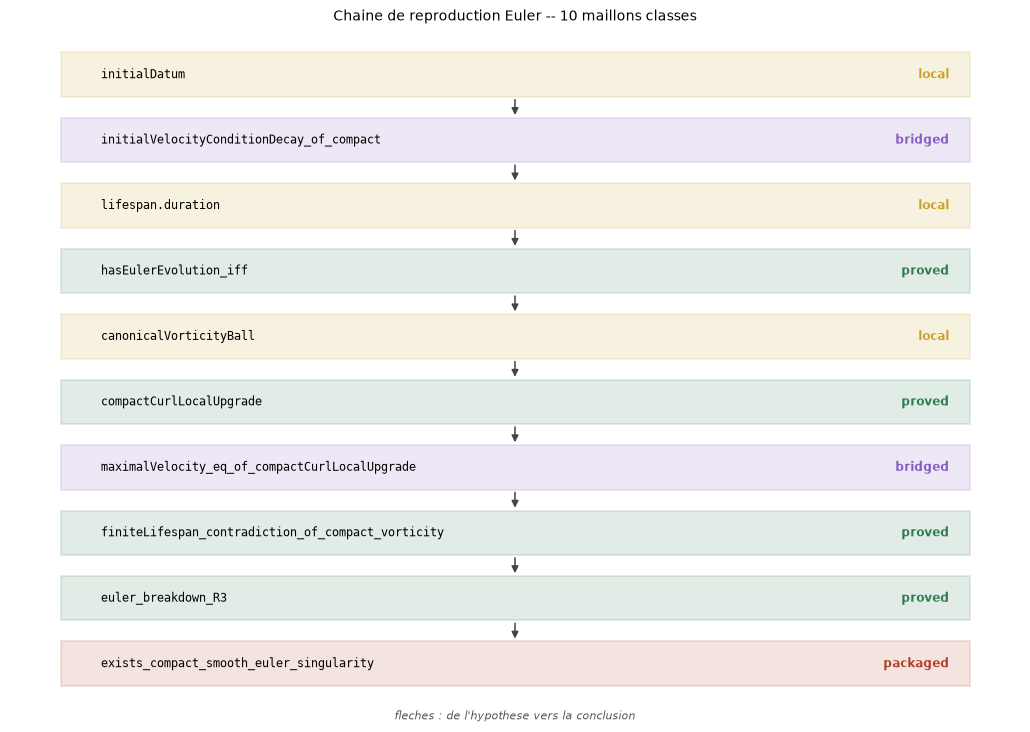

Repartition des classes : local=3, proved=4, bridged=2, packaged=1
Legende : upstream = amont, local = declare, proved = prouve,
          bridged = conversion de vocabulaire, packaged = assemblage.


In [4]:
# Code 2.2 - La chaine Euler en figure : chaque maillon colore par sa classe
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10.4, 7.4))
draw_chain(ax, EULER_CHAIN, "Chaine de reproduction Euler -- 10 maillons classes")
ax.text(0.5, 0.15, "fleches : de l'hypothese vers la conclusion",
        ha="center", fontsize=8, style="italic", color="#555555")
plt.tight_layout()
plt.show()

from collections import Counter

compte = Counter(classe for _n, classe, _d, _f in EULER_CHAIN)
print("Repartition des classes :",
      ", ".join(f"{classe}={compte[classe]}" for classe in CLASS_ENUM if compte[classe]))
print("Legende : upstream = amont, local = declare, proved = prouve,")
print("          bridged = conversion de vocabulaire, packaged = assemblage.")

### Lecture du résultat

La figure rend visible ce que le texte décrivait : la chaîne se lit de haut en bas, du datum initial (`initialDatum`) vers l'énoncé d'existence racine (`exists_…`), et la couleur de chaque boîte est sa classe. Trois régularités sautent aux yeux :

1. **l'alternance local / prouvé / converti** — les objets déclarés, les théorèmes et les deux conversions se relaient. Une chaîne exclusivement `local` ne prouverait rien ; une chaîne exclusivement `proved` cacherait d'où viennent ses objets ;
2. **les deux boîtes violettes (`bridged`) encadrent la partie prouvée** : une conversion d'entrée (`initialVelocityConditionDecay_of_compact`) et une conversion de sortie (`maximalVelocity_eq_of_compactCurlLocalUpgrade`). C'est le profil attendu d'une chaîne qui prouve dans un vocabulaire interne et rend son résultat dans le vocabulaire d'un défi ;
3. **aucune boîte grise (`upstream`)** — l'amont n'est pas un maillon, il est l'outillage des maillons.

La répartition affichée en bas de cellule est la **même information**, en chiffres : c'est elle que la section 4 agrègera avec les chaînes Navier–Stokes pour révéler les déséquilibres entre les branches.

## 3. Construction partagée, option (C), option (D)

### 3.1 Trois chaînes, et pourquoi il ne faut pas les confondre

Le fichier `NavierStokes/ComparatorSolution.lean` porte en tête :

> *« Navier–Stokes Comparator submission: options (C) and (D) »* — puis : *« Expose the project's proof adapters under the reference theorem names. The adapters import `ComparatorDefinitions`, never the challenge module »* (les adaptateurs importent `ComparatorDefinitions`, jamais le module du défi).

**Les options (C) et (D) sont deux soumissions au Comparator**, pas deux phases d'un même raisonnement. Chacune est une variante de l'énoncé de rupture, avec son propre vocabulaire de conditions initiales et de force :

| | **Option (C)** | **Option (D)** |
|---|---|---|
| Énoncé exposé | `NavierStokes.Comparator.navier_stokes_breakdown_R3` | `NavierStokes.Comparator.navier_stokes_breakdown_periodic` |
| Documenté comme | *« Breakdown of Navier–Stokes solutions on ℝ³ »* | *« Breakdown of Navier–Stokes solutions on ℝ³/ℤ³ »* |
| Conditions initiales | `Comparator.InitialVelocityConditionDecay u₀` | `Comparator.InitialVelocityConditionPeriodic u₀` |
| Force | `Comparator.ForceConditionDecay f` | `Comparator.ForceConditionPeriodic f` |
| Non-existence exigée | `¬ ∃ v p, Comparator.NavierStokesExistenceAndSmoothnessRn ν u₀ f v p` | `¬ ∃ v p, Comparator.NavierStokesExistenceAndSmoothnessPeriodic ν u₀ f v p` |
| Adaptateur interne | `option_C_of_compact_candidate` (`NavierStokes/ComparatorR3Theorem.lean`) | `option_D_of_candidate` (`NavierStokes/ComparatorTheorem.lean`) |
| Théorème de référence de l'adaptateur | `navier_stokes_breakdown_R3` | `navier_stokes_breakdown_periodic` |
| Témoin d'entrée | `R3CompactCandidate.Properties u p f` | `ProblemStatement.CandidateProperties u p f` |

**La construction du candidat est un troisième objet, partagé.** `ActualCandidateAssembly` produit un témoin (`selected_witness`), puis un candidat (`selected_candidate`, de type `ProblemStatement.candidateStatement`). Les deux branches le consomment, chacune par sa porte :

- la branche **(C)** passe par `R3ActualCandidate.selected_compact_candidate`, qui produit un `R3CompactCandidate.Properties` — la variante **ℝ³ entière** du candidat ;
- la branche **(D)** consomme directement `selected_candidate`, dont le type est le `CandidateProperties` **périodique**.

Appeler « option C » la construction partagée serait donc une erreur : la construction est **antérieure** au choix d'option, et elle est utilisée par les deux. C'est cette erreur que la décomposition en trois chaînes rend impossible à commettre.

**Deux modes d'exclusion, deux théorèmes amont internes.** Les deux adaptateurs n'excluent pas la solution globale par le même argument, et c'est là que leur différence est la plus substantielle :

| | Option (C) | Option (D) |
|---|---|---|
| Mécanisme | comparaison à **énergie finie sur tout ℝ³** : `R3FiniteEnergyComparison.compact_candidate_excludes_global_solution`, appuyé sur `NavierStokesR3.WholeSpaceUniqueness.classical_uniqueness_on_Icc` | **remise à l'échelle de viscosité** puis **durée de vie maximale** : `MaximalLifespan.candidate_excludes_global_solution`, appuyé sur `PeriodicUniqueness.classical_uniqueness_on_Icc` et `unbounded_excludes_continuous_extension` |
| Force utilisée | le candidat compact, remis à l'échelle par `ν²` | `f_ν(x,t) = ν² • f(ν·t, x)`, obtenue du candidat à viscosité 1 |
| Ce qui serait contradictoire | une solution globale à énergie finie uniforme pour la force compacte | une solution globale périodique, dont la restriction à `(0,2)` aurait une durée de vie `> 1` |
| Garantie d'indépendance | l'adaptateur conclut dans le vocabulaire `Comparator.*` sans nommer le module de défi | idem — en-tête : *« No result here uses any of the comparator's unproved statements »* |

Ces chaînes sont dites **d'adaptation** — et non de copie — parce qu'un port dans un lake CoursIA demanderait de choisir un cadre d'accueil cohérent en versions, d'adapter les estimateurs EDP et leurs dépendances, et de poser un probe par symbole. Copier un sous-arbre n'est pas une option : la règle de l'issue l'interdit explicitement.

construction partagee -- 3 maillons
 1. ActualCandidateConstruction [local   ] NavierStokes/ActualCandidateConstruction.lean
     module de construction : parameters / parameterSequence / cycle / ... (namespace NavierStokes.ActualCandidateConstruction)
 2. selected_witness       [proved  ] NavierStokes/ActualCandidateAssembly.lean
     theorem ActualCandidateAssembly.selected_witness : Witness ...
 3. selected_candidate     [proved  ] NavierStokes/ActualCandidateAssembly.lean
     theorem ActualCandidateAssembly.selected_candidate : ProblemStatement.candidateStatement

option (C) -- R3 -- 6 maillons
 1. selected_compact_candidate [proved  ] NavierStokes/R3ActualCandidate.lean
     theorem R3CompactCandidate.selected_compact_candidate : exists u p f, Properties u p f
 2. R3CompactCandidate.Properties [local   ] NavierStokes/R3CompactCandidate.lean
     structure R3CompactCandidate.Properties (u) (p) (f) : Prop
 3. compact_candidate_excludes_global_solution [proved  ] NavierStokes/R3Fini

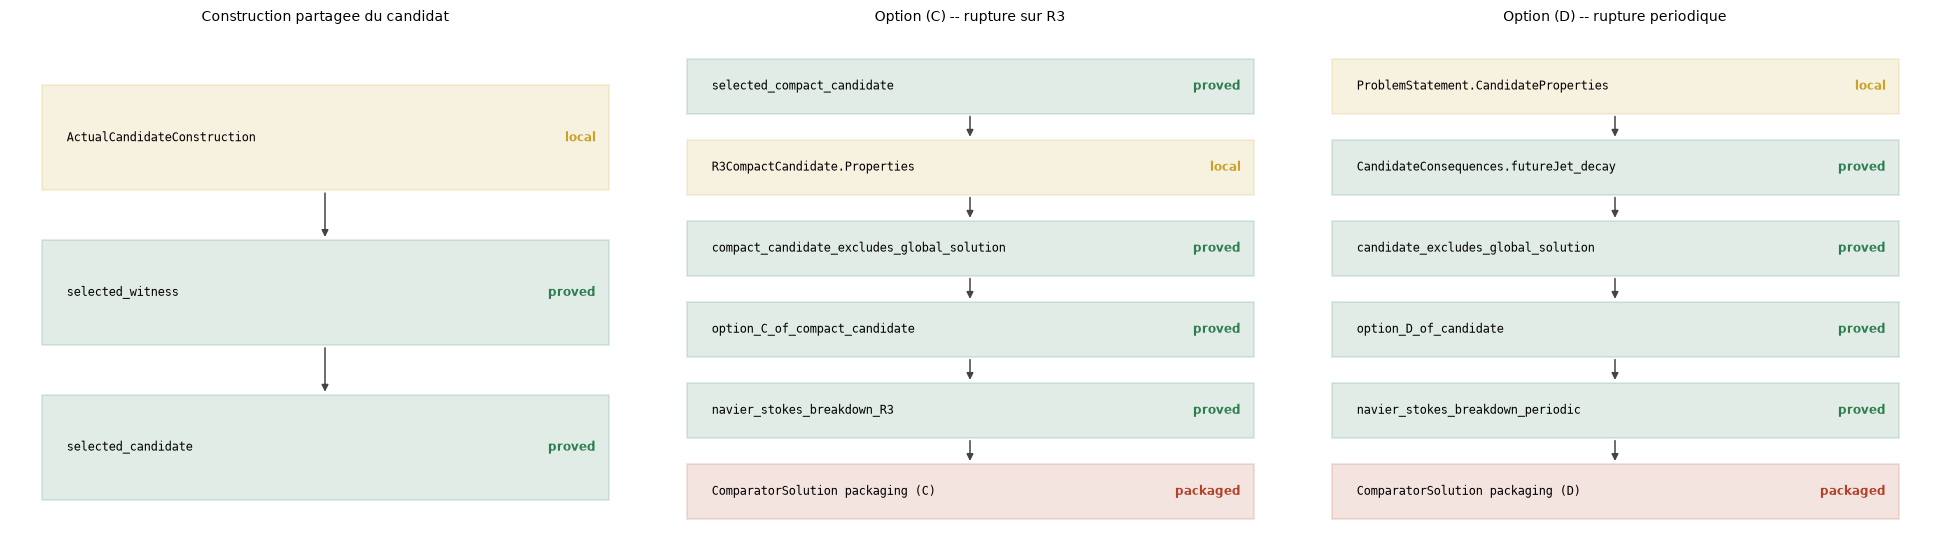

Lecture : la construction partagee alimente les DEUX options via deux portes
distinctes (selected_compact_candidate pour C, selected_candidate pour D).
Aucun maillon 'bridged' dans ces deux decompositions : la conversion de
vocabulaire est INTERNE aux adaptateurs, dont la conclusion est deja ecrite
dans le vocabulaire Comparator.* (contrairement a Euler, ou deux theoremes
de conversion nommes la portent).


In [5]:
# Code 3.1 - Trois chaines : construction partagee, option (C), option (D)
%matplotlib inline
import matplotlib.pyplot as plt

# Les options (C) et (D) sont les DEUX SOUMISSIONS du Comparator NS, telles que
# `NavierStokes/ComparatorSolution.lean` les expose. `NS_SHARED` est la construction
# de candidat, anterieure au choix d'option et consommee par les deux : l'appeler
# "option C" serait une erreur de lecture.
NS_SHARED = [
    ("ActualCandidateConstruction", "local",
     "module de construction : parameters / parameterSequence / cycle / ..."
     " (namespace NavierStokes.ActualCandidateConstruction)",
     "NavierStokes/ActualCandidateConstruction.lean"),
    ("selected_witness", "proved",
     "theorem ActualCandidateAssembly.selected_witness : Witness ...",
     "NavierStokes/ActualCandidateAssembly.lean"),
    ("selected_candidate", "proved",
     "theorem ActualCandidateAssembly.selected_candidate :"
     " ProblemStatement.candidateStatement",
     "NavierStokes/ActualCandidateAssembly.lean"),
]

NS_CHAIN_C = [
    ("selected_compact_candidate", "proved",
     "theorem R3CompactCandidate.selected_compact_candidate :"
     " exists u p f, Properties u p f",
     "NavierStokes/R3ActualCandidate.lean"),
    ("R3CompactCandidate.Properties", "local",
     "structure R3CompactCandidate.Properties (u) (p) (f) : Prop",
     "NavierStokes/R3CompactCandidate.lean"),
    ("compact_candidate_excludes_global_solution", "proved",
     "theorem (h : R3CompactCandidate.Properties u p f)"
     " (hv : GlobalSolutionRn f v q) : False",
     "NavierStokes/R3FiniteEnergyComparison.lean"),
    ("option_C_of_compact_candidate", "proved",
     "theorem (h : R3CompactCandidate.Properties u p f) (nu : R) (hnu : 0 < nu) :"
     " exists u0 f, Comparator.InitialVelocityConditionDecay u0 /\\"
     " Comparator.ForceConditionDecay f /\\ not (exists v p, ...Rn...)",
     "NavierStokes/ComparatorR3Theorem.lean"),
    ("navier_stokes_breakdown_R3", "proved",
     "theorem NavierStokes.ComparatorBridge.navier_stokes_breakdown_R3 (nu) (hnu)",
     "NavierStokes/ComparatorR3Theorem.lean"),
    ("ComparatorSolution packaging (C)", "packaged",
     "theorem NavierStokes.Comparator.navier_stokes_breakdown_R3 (nu) (hnu) :="
     " ComparatorBridge.navier_stokes_breakdown_R3 nu hnu",
     "NavierStokes/ComparatorSolution.lean"),
]

NS_CHAIN_D = [
    ("ProblemStatement.CandidateProperties", "local",
     "structure CandidateProperties (u) (p) (f) : Prop",
     "NavierStokes/ProblemStatement.lean"),
    ("CandidateConsequences.futureJet_decay", "proved",
     "decroissance des jets futurs de la force periodique a support temporel compact",
     "NavierStokes/CandidateConsequences.lean"),
    ("candidate_excludes_global_solution", "proved",
     "theorem MaximalLifespan.candidate_excludes_global_solution"
     " (h : CandidateProperties u p f) (hv) (hq) (hpv) (hpq) (hvzero)"
     " (hdv) (hNSv) : False",
     "NavierStokes/MaximalLifespan.lean"),
    ("option_D_of_candidate", "proved",
     "theorem (h : CandidateProperties u p f) (nu : R) (hnu : 0 < nu) :"
     " exists u0 f, Comparator.InitialVelocityConditionPeriodic u0 /\\"
     " Comparator.ForceConditionPeriodic f /\\ not (exists v p, ...Periodic...)",
     "NavierStokes/ComparatorTheorem.lean"),
    ("navier_stokes_breakdown_periodic", "proved",
     "theorem NavierStokes.ComparatorBridge.navier_stokes_breakdown_periodic (nu) (hnu)",
     "NavierStokes/ComparatorTheorem.lean"),
    ("ComparatorSolution packaging (D)", "packaged",
     "theorem NavierStokes.Comparator.navier_stokes_breakdown_periodic (nu) (hnu) :="
     " ComparatorBridge.navier_stokes_breakdown_periodic nu hnu",
     "NavierStokes/ComparatorSolution.lean"),
]

for titre, chaine in (("construction partagee", NS_SHARED),
                      ("option (C) -- R3", NS_CHAIN_C),
                      ("option (D) -- periodique", NS_CHAIN_D)):
    print(f"{titre} -- {len(chaine)} maillons")
    for index, (name, classe, decl, fichier) in enumerate(chaine, start=1):
        print(f"{index:2d}. {name:22s} [{classe:8s}] {fichier}")
        print(f"     {decl}")
    print()

fig, axes = plt.subplots(1, 3, figsize=(19.5, 5.6))
draw_chain(axes[0], NS_SHARED, "Construction partagee du candidat")
draw_chain(axes[1], NS_CHAIN_C, "Option (C) -- rupture sur R3")
draw_chain(axes[2], NS_CHAIN_D, "Option (D) -- rupture periodique")
plt.tight_layout()
plt.show()

print("Lecture : la construction partagee alimente les DEUX options via deux portes")
print("distinctes (selected_compact_candidate pour C, selected_candidate pour D).")
print("Aucun maillon 'bridged' dans ces deux decompositions : la conversion de")
print("vocabulaire est INTERNE aux adaptateurs, dont la conclusion est deja ecrite")
print("dans le vocabulaire Comparator.* (contrairement a Euler, ou deux theoremes")
print("de conversion nommes la portent).")

### Lecture du résultat

Les trois chaînes ont des **profils de classes distincts**, et c'est cela qu'il faut retenir :

| | Construction partagée | Option (C) | Option (D) |
|---|---|---|---|
| Longueur | 3 maillons | 6 maillons | 6 maillons |
| Dominante | `proved` + `local` | `proved` | `proved` |
| Emprunt amont nommé | — | — | — |
| Maillon `bridged` | — | — | — |
| Point d'assemblage | `selected_candidate` | porte d'entrée `selected_compact_candidate` | porte d'entrée `selected_candidate` |
| Empaquetage final | — | `ComparatorSolution` | `ComparatorSolution` |

Quatre conséquences, qui sont l'apport propre de cette section :

1. **la construction partagée n'est pas « l'option C ».** Sa porte d'entrée vers (C) est un théorème distinct (`R3ActualCandidate.selected_compact_candidate`) de son point d'arrivée (`selected_candidate`) ; la confondre avec (C) ferait disparaître la seule ligne de la figure qui explique pourquoi les deux options sont comparables ;
2. **les deux options se ressemblent structurellement** — même longueur, même absence de pont nommé, même empaquetage dans `ComparatorSolution` — et ne diffèrent que par le mécanisme d'exclusion et l'énoncé exposé. C'est le signe d'une **soumission double délibérée** : le projet veut que le même résultat soit disponible dans les deux vocabulaires du défi, pas qu'un raisonnement passe de l'un à l'autre ;
3. **il n'y a aucun maillon `bridged` dans ces décompositions**, alors qu'Euler en compte deux. Ce n'est pas une asymétrie de soin : les adaptateurs Navier–Stokes concluent **directement** dans le vocabulaire `Comparator.*` (`Comparator.InitialVelocityConditionDecay`, `Comparator.NavierStokesExistenceAndSmoothnessRn`, `…Periodic…`), donc la conversion est *interne* au théorème prouvé plutôt que d'être un maillon nommé. Côté Euler, le vocabulaire du défi est un `structure` (`InitialVelocityConditionDecay`) qu'un théorème séparé doit atteindre, et la représentation de solution doit être identifiée — d'où deux maillons `bridged` visibles ;
4. **le point d'appui interne est asymétrique.** (C) s'appuie sur la comparaison à énergie finie sur ℝ³ ; (D) s'appuie sur la durée de vie maximale et la remise à l'échelle de viscosité. Adapter l'une **ou** l'autre demande donc deux cadres de bibliothèque différents — c'est une information de décision, pas un détail.

> **Rappel de portée** : dans les deux cas, la conclusion porte sur **le candidat construit**, pas sur une solution quelconque. Ce que cela permet et ne permet pas de conclure est l'objet de la section 6, et c'en est le point le plus important.

## 4. Classer les maillons

### 4.1 Les cinq classes, définitions opératoires

Une classification n'a de valeur que si ses classes sont **testables**. Les cinq classes du protocole se définissent donc par un critère qu'on peut trancher en ouvrant le dépôt :

| Classe | Définition opératoire | Test de terrain |
|---|---|---|
| `upstream` | fourni par la bibliothèque amont (Mathlib, lake pinné) ; le dépôt le **consomme** | le symbole se résout sans être déclaré dans le dépôt |
| `local` | **déclaré** dans le dépôt, sans contenu de théorème à lui seul | `def` / `structure` / `abbrev`, ou construction sans preuve close |
| `proved` | porte la **substance** : un théorème établi dans le dépôt | `theorem` / `lemma` dont la preuve est close |
| `bridged` | **traduit** entre deux vocabulaires ou deux représentations (ℝ³ ↔ 𝕋³, interface interne ↔ interface de défi) | l'énoncé convertit sans ajouter de mathématiques nouvelles |
| `packaged` | **couche d'assemblage** qui rassemble des sous-résultats sous un nom de référence | extraction d'un témoin, espace de noms `Assembly`, ré-exposition sous un nom du défi |

Deux règles de discipline accompagnent cette grille :

- **une classe par maillon**. Un maillon mixte reçoit la classe de son **rôle dominant**, et la note signalerait explicitement la mixture. Refuser de trancher reviendrait à rendre la classe inutilisable ;
- **l'énumération est fermée**. Un maillon dont la classe sortirait des cinq valeurs est un **défaut de classification**, pas une sixième classe. La cellule suivante le vérifie.

Le point sensible de la grille est la frontière `proved` / `bridged` / `packaged` :

- un théorème qui **démontre** une propriété mathématique est `proved`, même si son énoncé parle de deux objets ;
- un théorème dont le contenu est **l'identification de deux écritures du même objet** est `bridged` ;
- un théorème qui **ne démontre rien de neuf** et se contente de ré-exposer un résultat existant sous un nom attendu est `packaged`.

Les deux adaptations Navier–Stokes de `ComparatorSolution.lean` tombent dans la troisième catégorie : leur corps est un unique appel à l'adaptateur (`exact ComparatorBridge.navier_stokes_breakdown_R3 nu hnu`). Les compter comme `proved` gonflerait artificiellement la substance et masquerait que **le contenu est dans l'adaptateur**, pas dans la ré-exposition.

chaine         upstream     local    proved   bridged  packaged   total
Euler                 0         3         4         2         1      10
NS partagee           0         1         2         0         0       3
NS (C)                0         1         4         0         1       6
NS (D)                0         1         4         0         1       6

Total : 25 maillons
Classes hors enumeration : aucune
Maillons sans fichier    : aucun
Classes jamais utilisees : ['upstream']
Ou apparait 'bridged'    : ['Euler']


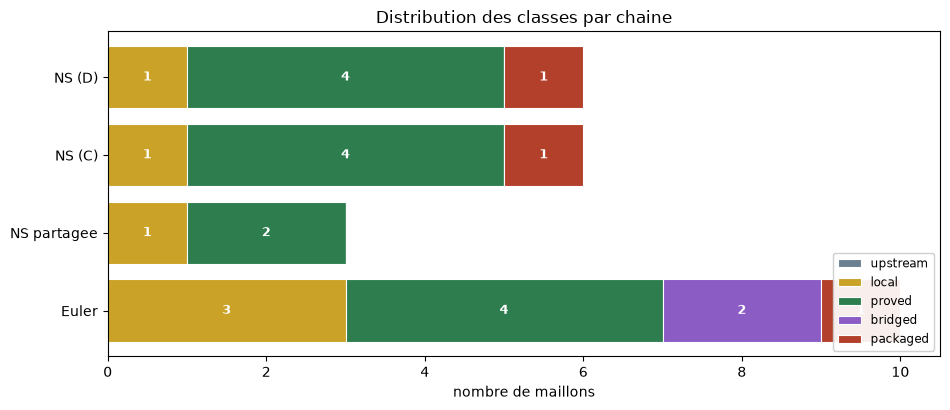

In [6]:
# Code 4.1 - Comptage par classe, validation de l'enumeration, figure de synthese
%matplotlib inline
import matplotlib.pyplot as plt

CHAINS = {
    "Euler": EULER_CHAIN,
    "NS partagee": NS_SHARED,
    "NS (C)": NS_CHAIN_C,
    "NS (D)": NS_CHAIN_D,
}

comptes = {titre: {classe: 0 for classe in CLASS_ENUM} for titre in CHAINS}
hors_enum = []
sans_fichier = []
for titre, chaine in CHAINS.items():
    for name, classe, decl, fichier in chaine:
        if classe in CLASS_ENUM:
            comptes[titre][classe] += 1
        else:
            hors_enum.append((titre, name, classe))
        if not fichier.endswith(".lean"):
            sans_fichier.append((titre, name, fichier))

entete = " ".join(f"{classe:>9s}" for classe in CLASS_ENUM)
print(f"{'chaine':13s} {entete}   total")
for titre in CHAINS:
    ligne = " ".join(f"{comptes[titre][classe]:9d}" for classe in CLASS_ENUM)
    print(f"{titre:13s} {ligne}   {len(CHAINS[titre]):5d}")

total = sum(len(chaine) for chaine in CHAINS.values())
print(f"\nTotal : {total} maillons")
print(f"Classes hors enumeration : {hors_enum if hors_enum else 'aucune'}")
print(f"Maillons sans fichier    : {sans_fichier if sans_fichier else 'aucun'}")
jamais = [c for c in CLASS_ENUM if all(comptes[t][c] == 0 for t in CHAINS)]
print(f"Classes jamais utilisees : {jamais if jamais else 'aucune'}")
print(f"Ou apparait 'bridged'    : "
      f"{[t for t in CHAINS if any(c == 'bridged' for _n, c, _d, _f in CHAINS[t])] or 'nulle part'}")

fig, ax = plt.subplots(figsize=(9.6, 4.2))
positions = list(range(len(CHAINS)))
cumul = [0] * len(CHAINS)
for classe in CLASS_ENUM:
    valeurs = [comptes[titre][classe] for titre in CHAINS]
    ax.barh(positions, valeurs, left=cumul, color=CLASS_COLORS[classe],
            edgecolor="white", linewidth=0.8, label=classe)
    for y, (valeur, decalage) in enumerate(zip(valeurs, cumul)):
        if valeur:
            ax.text(decalage + valeur / 2, y, str(valeur), ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    cumul = [a + b for a, b in zip(cumul, valeurs)]
ax.set_yticks(positions)
ax.set_yticklabels(list(CHAINS))
ax.set_xlabel("nombre de maillons")
ax.set_title("Distribution des classes par chaine")
ax.legend(loc="lower right", fontsize=8.5, framealpha=0.92)
plt.tight_layout()
plt.show()

### Lecture du résultat

Le tableau et la figure donnent la **même mesure sous deux formes**. Ce qu'ils révèlent :

| Mesure | Valeur observée | Ce qu'elle signifie |
|---|---|---|
| Classe hors énumération | aucune | la grille des cinq classes **recouvre** les vingt-cinq maillons : la classification est applicable telle quelle |
| Maillon sans fichier `.lean` | aucun | chaque maillon est rattaché à une déclaration située : la classification est **auditable ligne à ligne** |
| Classe jamais utilisée | `upstream` | aucune chaîne ne compte l'amont comme maillon — Mathlib outille les preuves sans y figurer |
| Localisation de `bridged` | Euler uniquement | les adaptateurs Navier–Stokes concluent directement dans le vocabulaire du défi ; Euler a besoin de deux théorèmes de conversion nommés |

La deuxième ligne est celle qui distingue cette classification d'un jugement de rôle : chaque entrée porte un fichier, donc un lecteur peut ouvrir le fichier et contredire la classe. Une classe qu'on ne peut pas contredire n'informe personne.

Les barres de la figure rendent visible le contraste de **profil** : partout dominées par les théorèmes (`proved`), avec les portions jaunes (`local`) qui marquent les objets déclarés et les portions rouges (`packaged`) qui marquent les ré-expositions sous un nom de défi.

**Ce que ce comptage ne prouve pas** : qu'une classe soit « mieux » qu'une autre. Un maillon `local` n'est pas un maillon faible — une chaîne de preuve a besoin d'objets bien posés. Le comptage sert à **localiser la substance**, pas à noter la chaîne.

> **Le contrôle qui reste possible** : ouvrir chaque fichier cité et vérifier l'appartenance de classe — un `proved` qui porterait un `sorry`, un `bridged` qui démontrerait en fait un théorème de contenu, un `packaged` qui aurait un corps non trivial. Les fichiers sont nommés précisément pour que ce contrôle soit possible, et il peut **contredire** ce tableau.

## 5. Re-dériver le verdict depuis les feuilles

### 5.1 Ne pas croire `all_verified`

Le rapport du harnais porte un champ de synthèse, `all_verified`. Le réflexe naturel — le lire et le croire — est exactement le réflexe qu'un vérificateur doit combattre : **un résumé est une affirmation, les feuilles sont l'évidence**. La conjonction du harnais se recompose ainsi, avec **huit** termes :

$$
\texttt{all\_verified} \;=\; \texttt{sha\_matches\_pin} \;\wedge\; \texttt{dependency\_pins\_match} \;\wedge\; \texttt{toolchain\_matches} \;\wedge\; \texttt{confinement.verified} \;\wedge\; \texttt{axioms\_within\_permitted} \;\wedge\; \texttt{forbidden\_axioms} = [\,] \;\wedge\; \texttt{integrity.verified} \;\wedge\; \bigwedge_{\text{gate}} \texttt{gate.verified}
$$

Trois de ces termes sont faciles à oublier dans une re-dérivation écrite de mémoire : `dependency_pins_match` (les revs de `Comparator`, `mathlib`, `lean4export` **et** le rev du noyau nanoda), `confinement.verified` (identité de `landrun` et probe fonctionnel refus/autorisation) et `integrity.verified` (le recensement externe des sources suivies). Un rapport dont les gates sont verts mais l'un de ces trois termes faux n'est pas une reproduction confinée.

Chaque `gate.verified` se décompose à son tour en quatre feuilles :

| Feuille du gate | Condition |
|---|---|
| processus | statut `ok`, code de sortie enfant nul, code de sortie nul, processus **non tué** |
| orphelins | la postcondition d'orphelins est satisfaite (aucun processus résiduel) |
| sémantique | les **deux** kernels acceptent, le verdict de succès est présent, aucune marque de rejet |
| empreinte | l'empreinte du JSON de challenge égale l'empreinte attendue |

La cellule suivante recalcule cette conjonction **à partir des feuilles** et la compare au champ déclaré. Elle exige exactement les deux gates attendus, vérifie les onze sondes axiomatiques, les quatre signatures de placeholders et la forme des empreintes annoncées.

In [7]:
# Code 5.1 - Re-derivation independante de la conjonction, feuille par feuille
#
# Le rapport porte un champ de synthese `all_verified`. On ne le lit pas comme une
# preuve : on recalcule la conjonction depuis les feuilles, puis on compare.
# Le moindre desaccord est un finding -- pas un detail d'affichage.
EXPECTED_GATES = {"euler", "navier_stokes"}
EXPECTED_CHALLENGE_SORRIES = {
    ("ComparatorChallenges/Euler.lean", "euler_breakdown_R3", 1),
    ("ComparatorChallenges/Euler.lean", "exists_compact_smooth_euler_singularity", 1),
    ("ComparatorChallenges/NavierStokes.lean", "navier_stokes_breakdown_R3", 1),
    ("ComparatorChallenges/NavierStokes.lean", "navier_stokes_breakdown_periodic", 1),
}


def gate_verified(gate):
    """Recalcule les quatre feuilles d'un gate, sans lire son résumé `verified`."""
    leaves = {
        "process_ok": (
            gate.get("status") == "ok"
            and gate.get("child_exit_code") == 0
            and gate.get("exit_code") == 0
            and gate.get("killed") is False
        ),
        "orphan_ok": gate.get("orphans") == [] and bool(
            gate.get("orphan_postcondition_ok")
        ),
        "semantic_ok": (
            gate.get("kernels") == {"nanoda": "accepts", "lean_kernel": "accepts"}
            and gate.get("semantic_verdict") == "Your solution is okay!"
            and gate.get("semantic_rejection") is False
        ),
        "hash_ok": bool(gate.get("challenge_hash_matches")),
    }
    return all(leaves.values()), leaves


def rederive_all_verified(report, gates, integrity):
    """Recalcule les huit termes du harnais depuis les feuilles disponibles."""
    named_axioms = report.get("axiom_declarations")
    challenge_sorries = integrity.get("challenge_sorry_locations")
    observed_sorries = {
        (item.get("file"), item.get("declaration"), item.get("count"))
        for item in challenge_sorries
        if isinstance(item, dict)
    } if isinstance(challenge_sorries, list) else set()
    gate_leaves = {name: gate_verified(gate)[0] for name, gate in gates.items()}
    confinement = report.get("confinement")
    conditions = {
        "sha_matches_pin": (
            bool(report.get("sha_matches_pin"))
            and report.get("observed_sha") == PINNED_SHA
        ),
        "dependency_pins_match": bool(report.get("dependency_pins_match")),
        "toolchain_matches": (
            bool(report.get("toolchain_matches"))
            and report.get("toolchain") == TOOLCHAIN
        ),
        "confinement_verified": (
            isinstance(confinement, dict)
            and confinement.get("engine") == "landrun"
            and confinement.get("version") == "landrun version 0.1.17"
            and confinement.get("unauthorized_write_denied") is True
            and confinement.get("authorized_write_allowed") is True
            and confinement.get("verified") is True
        ),
        "axioms_within_permitted": (
            bool(report.get("axioms_within_permitted"))
            and isinstance(named_axioms, list)
            and len(named_axioms) == len(set(named_axioms))
            and set(named_axioms) == set(EXPECTED_AXIOM_DECLARATIONS)
        ),
        "aucun_axiome_interdit": report.get("forbidden_axioms") == [],
        "integrity_verified": (
            bool(integrity.get("verified"))
            and observed_sorries == EXPECTED_CHALLENGE_SORRIES
            and integrity.get("solution_sorry_proof_count") == 0
            and integrity.get("native_decide_count") == 0
        ),
        "tous_les_gates_verifies": (
            set(gates) == EXPECTED_GATES and all(gate_leaves.values())
        ),
    }
    return all(conditions.values()), conditions, gate_leaves


rederived, conditions, gate_leaves = rederive_all_verified(REPORT, GATES, INTEGRITY)
for nom, valeur in conditions.items():
    print(f"  {nom:26s} : {valeur}")
declare = bool(REPORT.get("all_verified"))
print()
print(f"  conjonction recalculee : {rederived}")
print(f"  champ declare          : {declare}")
print(f"  concordance            : {rederived == declare}")
print()
print("  Feuilles par gate (recalculees sans lire `gate.verified`) :")
for nom, gate in sorted(GATES.items()):
    verified, leaves = gate_verified(gate)
    print(f"    {nom:14s} process={leaves['process_ok']} "
          f"orphelins={leaves['orphan_ok']} semantique={leaves['semantic_ok']} "
          f"empreinte={leaves['hash_ok']} -> recalcule={verified} "
          f"declare={gate.get('verified')}")
print()
print("  Recensement d'integrite :")
for cle in ("scanner", "tracked_lean_files", "root_sha_matches",
            "challenge_sorry_proof_count", "solution_sorry_proof_count",
            "native_decide_count", "complete", "verified"):
    print(f"    {cle:30s} : {field(INTEGRITY, cle)}")
observed_signature = {
    (item.get("file"), item.get("declaration"), item.get("count"))
    for item in INTEGRITY.get("challenge_sorry_locations", [])
    if isinstance(item, dict)
}
print(f"    signatures challenge exactes : {observed_signature == EXPECTED_CHALLENGE_SORRIES}")
print()
print("  Empreintes observees vs attendues :")
for nom in sorted(EXPECTED_CHALLENGE_SHA256):
    observee = GATES.get(nom, {}).get("challenge_sha256", "<absent>")
    attendue = EXPECTED_CHALLENGE_SHA256[nom]
    verdict = "concordent" if observee == attendue else "DESACCORD"
    print(f"    {nom:14s} {str(observee)[:20]}... vs {attendue[:20]}...  -> {verdict}")
print()
print("  Forme des empreintes -- 64 hex attendus pour les challenges :",
      all(re.fullmatch(r"[0-9a-f]{64}", h) for h in EXPECTED_CHALLENGE_SHA256.values()),
      "| 40 hex attendus pour le pin :", bool(re.fullmatch(r"[0-9a-f]{40}", PINNED_SHA)))
print()
print("  Preuves d'axiomes nommees :")
OBSERVED_DECLS = REPORT.get("axiom_declarations")
if isinstance(OBSERVED_DECLS, list):
    observed_set = set(OBSERVED_DECLS)
    expected_set = set(EXPECTED_AXIOM_DECLARATIONS)
    print("    conjonction d'ensembles :",
          "IDENTIQUE" if observed_set == expected_set else "DESACCORD")
    print(f"    cibles manquees    : {sorted(expected_set - observed_set) or 'aucune'}")
    print(f"    sondes inattendues : {sorted(observed_set - expected_set) or 'aucune'}")
    print(f"    nombre de sondes   : {len(OBSERVED_DECLS)} observe,"
          f" {len(EXPECTED_AXIOM_DECLARATIONS)} attendu")
else:
    print("    champ axiom_declarations ABSENT du rapport -- preuve nommee indisponible")
print(f"    chaque sonde porte exactement le trio permis :"
      f" {field(REPORT, 'axioms_within_permitted')}")

  sha_matches_pin            : True
  dependency_pins_match      : True
  toolchain_matches          : True
  confinement_verified       : True
  axioms_within_permitted    : True
  aucun_axiome_interdit      : True
  integrity_verified         : True
  tous_les_gates_verifies    : True

  conjonction recalculee : True
  champ declare          : True
  concordance            : True

  Feuilles par gate (recalculees sans lire `gate.verified`) :
    euler          process=True orphelins=True semantique=True empreinte=True -> recalcule=True declare=True
    navier_stokes  process=True orphelins=True semantique=True empreinte=True -> recalcule=True declare=True

  Recensement d'integrite :
    scanner                        : scripts/lean/count_code_sorry.py:scan_file
    tracked_lean_files             : 2486
    root_sha_matches               : True
    challenge_sorry_proof_count    : 4
    solution_sorry_proof_count     : 0
    native_decide_count            : 0
    complete            

### Lecture du résultat

Trois enseignements de nature différente, qu'il faut garder séparés.

**1. La re-dérivation rend le recouvrement des clauses d'axiomes visible.** `axioms_within_permitted` exige que les onze déclarations sondées soient exactement les cibles attendues, chacune portant exactement le trio permis — et le harnais est durci : un sondage **répété** annule la preuve nommée au lieu de grossir le compte ; `forbidden_axioms`, lui, balaie **toutes** les listes d'axiomes imprimées. Les deux clauses se recouvrent largement sans être logiquement identiques — l'une certifie les cibles, l'autre surveille tout ce qui s'imprime. Les garder toutes deux dans la conjonction est une ceinture et des bretelles, et la re-dérivation permet de le **constater** au lieu de le supposer.

**2. Trois termes de la conjonction sont invisibles depuis les gates.** `dependency_pins_match`, `confinement.verified` et `integrity.verified` ne se lisent nulle part dans les enregistrements `gate`. Un lecteur qui aurait contrôlé les deux gates un par un — kernels, empreintes, verdict sémantique, orphelins — aurait pu déclarer la reproduction valide sans vérifier les dépendances, l'application fonctionnelle du confinement ou la complétude du recensement des sources suivies. **C'est le principal apport de cette section** : la liste des feuilles n'est pas devinable depuis les objets les plus visibles du rapport.

Le probe de confinement ne se contente pas du nom d'un binaire : il exige `landrun version 0.1.17`, vérifie qu'une écriture non autorisée sous le home est refusée et qu'une écriture explicitement autorisée sous `/tmp` réussit. Les deux observations sont nécessaires ; un binaire présent mais inopérant ne suffit pas.

**3. Les empreintes et signatures sont confrontées aux contrats exacts.** Les empreintes observées sont affichées face aux attendues. Le recensement compare également les quatre triplets `(fichier, déclaration, compte)` des placeholders de challenge, exige zéro placeholder dans les solutions et zéro `native_decide`. Un total de quatre sans localisation exacte serait insuffisant : déplacer un trou du challenge vers une solution conserverait le total tout en détruisant l'intégrité recherchée.

> **Note de méthode** : c'est la fonction d'un organe de contrôle que de rendre la conjonction **recomposable** plutôt que de la laisser dormir dans un booléen. La section 7 en fait un exercice.

> **Note — les onze cibles d'axiomes et les chaînes de ce notebook**. Les déclarations sondées par le harnais sont énumérées nommément : les deux adaptateurs, leurs deux théorèmes d'exclusion, les quatre énoncés exigés par les deux challenges, les deux théorèmes BKM — et la contrepartie au niveau *packet* du dernier maillon d'Euler, homonyme exact de celui-ci. Que seuls les noms **qualifiés** distinguent les homonymes est une raison de plus pour confronter l'ensemble observé aux onze cibles, au lieu de se fier au seul compte.

> **Note — les quatre `sorry` de challenge**. La signature exacte exige un placeholder pour `euler_breakdown_R3` et `exists_compact_smooth_euler_singularity` dans `ComparatorChallenges/Euler.lean`, puis un pour `navier_stokes_breakdown_R3` et `navier_stokes_breakdown_periodic` dans `ComparatorChallenges/NavierStokes.lean`. Ce sont les trous attendus du côté défi ; côté solution, le compte doit rester à zéro.

## 6. Portée, limites et non-claims

Cette section est la plus importante du notebook, parce qu'elle énonce ce que **rien** de ce qui précède ne permet de conclure.

### 6.1 Ce qu'un gate vert établit

Le rapport porte `all_verified: true` avec l'ensemble de ses huit termes satisfaits. Les faits suivants sont alors établis :

| Fait établi | Portée exacte |
|---|---|
| le checkout est au pin `8937a8f4…` | identité du **code source** examiné |
| les pins de dépendances concordent | reproductibilité de la **chaîne de dépendances**, pas seulement de l'arbre principal |
| la toolchain est celle déclarée | reproductibilité de l'**outillage** |
| le confinement est fonctionnel | `landrun` est à la version attendue ; une écriture hors périmètre est refusée et une écriture autorisée réussit |
| les deux kernels acceptent l'artefact | l'artefact est **dérivable** dans le noyau Lean standard **et** dans un noyau alternatif indépendant (nanoda) |
| les seuls axiomes utilisés sont `propext`, `Classical.choice`, `Quot.sound` | les onze déclarations porteuses sont sondées **nommément**, chacune avec exactement ce trio — pas de `sorryAx` transitif, pas de réduction par le noyau natif déguisée |
| le recensement d'intégrité est complet et vérifié | les quatre signatures attendues sont localisées côté challenge ; les solutions portent zéro `sorry` et zéro `native_decide` |
| aucun processus orphelin ne subsiste | la mesure n'a pas été polluée par un processus résiduel |

### 6.2 Ce qu'un gate vert n'établit **pas**

| Non-claim | Pourquoi |
|---|---|
| **que l'exposition est juste** | le noyau vérifie un artefact, pas la lecture qu'on en fait ; les sections 2 et 3 sont de l'exposition |
| **que l'énoncé est nouveau ou intéressant** | la vérification est aveugle à la valeur mathématique et à l'antériorité |
| **qu'un lecteur humain accepterait la preuve** | l'acceptation mécanique ne remplace pas la relecture, elle la déplace |
| **que la classification de la section 4 est exacte** | elle est fondée sur des déclarations citées, donc réfutable — mais elle n'a pas été recontrôlée fichier par fichier dans ce notebook |
| **que le candidat est l'objet que le défi visait** | les adaptateurs prouvent une propriété du candidat **construit** ; l'identification de cet objet à un objet mathématiquement intéressant est un jugement externe |
| **que le problème du millénaire sur Navier–Stokes est résolu** | voir 6.3 — c'est le point le plus important |

### 6.3 Le non-claim central

**Ce notebook n'affirme pas, et le rapport du harnais n'établit pas, que le problème du millénaire sur l'existence et la régularité des solutions de Navier–Stokes soit résolu.**

Ce qui est rapporté est plus étroit, et doit être énoncé avec précision. Les deux adaptateurs établissent une propriété d'**exclusion portant sur le candidat construit** :

- l'option (C) exclut toute solution globale à énergie finie uniforme pour la force compacte remise à l'échelle, par comparaison sur ℝ³ entier ;
- l'option (D) exclut toute solution globale périodique pour la force `f_ν`, en la remettant à l'échelle vers une solution globale à viscosité 1, ce qui contredit la durée de vie maximale égale à un.

Dans les deux cas, le théorème d'exclusion est **conditionné à l'existence du témoin de candidat**, obtenu par `selected_candidate` / `selected_compact_candidate`. Trois écarts séparent une telle affirmation d'une résolution du problème du millénaire, et aucun n'est franchi par une acceptation de noyau :

1. **l'écart de portée** : une exclusion portant sur *un* candidat n'est pas une exclusion portant sur *toutes* les solutions admissibles ;
2. **l'écart d'énoncé** : faire coïncider l'énoncé formel des challenges Comparator et l'énoncé précis du problème du millénaire est un travail mathématique, non un travail de vérification ;
3. **l'écart d'arbitrage** : décider qu'un énoncé formalisé *est bien* l'énoncé du problème est un jugement de communauté, qui ne se délègue ni à un noyau ni à un notebook.

Un noyau est un instrument d'une **précision** remarquable et d'une **portée** étroite : il dit qu'une dérivation est correcte, jamais que le problème visé est celui qu'on croit.

### 6.4 Une contrainte d'environnement, pas de mathématiques

Les exécutions Comparator que le harnais relit ont tourné sous un sandbox noyau — `landrun`, fondé sur **Landlock** de Linux — et leurs artefacts vivent dans un home WSL. Un hôte Windows natif ne peut pas les rejouer directement : ce n'est ni une impossibilité mathématique ni une raison de dégrader la mesure. Le probe fonctionnel du rapport démontre ici que le mécanisme requis était actif.

| Situation | Lecture correcte |
|---|---|
| un échec local du sandbox | « cet hôte ne porte pas le mécanisme requis » — jamais « l'outil est intrinsèquement impossible » |
| un `all_verified: false` | « le gate n'a pas été franchi **ici** », pas « le résultat est faux » |
| un succès local | l'artefact est accepté **pour ces pins** — pas une validité générale, pas une preuve de nouveauté |

## 7. Exercices

Les trois exercices suivants prolongent le notebook sans le répéter : ils portent sur la **réutilisation** de ce qui a été démontré, pas sur sa recopie. Chacun s'appuie sur des objets déjà en mémoire et demande un travail que les cellules de démonstration n'ont pas fait.

### Exercice 1 — Re-dériver le prédicat d'un gate à partir de ses quatre feuilles

La cellule 5.1 a recalculé la conjonction **au niveau du rapport**, en prenant `gate.verified` comme donné. L'exercice demande de descendre d'un cran : reconstruire `verified` **depuis les feuilles** d'un enregistrement de gate.

**Objectif** : écrire une fonction réutilisable `gate_verified(gate)` qui retourne le booléen **et** le détail des quatre feuilles.

**Étapes** :

1. `process_ok` — statut `ok`, code de sortie enfant nul, code de sortie nul, processus non tué ;
2. `orphan_ok` — la postcondition d'orphelins est satisfaite ;
3. `semantic_ok` — les deux kernels acceptent, le verdict sémantique est présent, aucune marque de rejet ;
4. `hash_ok` — la concordance d'empreinte ; puis `verified` = conjonction des quatre.

**Pourquoi c'est utile** : une fonction de ce type est ce qui permet de rejouer un rapport **ancien** contre les règles **courantes**, et donc de détecter qu'une règle de vérification a changé — ce qu'un champ de synthèse figé ne peut pas signaler. Attention à l'ordre : une feuille oubliée rend la fonction **plus permissive** que le harnais, ce qui est le sens de l'erreur le plus dangereux.

In [8]:
# Exercice 1 - Re-deriver le predicat d'un gate depuis ses quatre feuilles
# Etape 1 : process_ok  = status == "ok" ET child_exit_code == 0 ET exit_code == 0 ET killed is False
# Etape 2 : orphan_ok   = la postcondition d'orphelins est satisfaite
# Etape 3 : semantic_ok = les deux kernels acceptent ET le verdict semantique est present
#                        ET aucune rejection n'a ete detectee
# Etape 4 : hash_ok     = challenge_hash_matches est vrai
#           verified    = process_ok ET orphan_ok ET semantic_ok ET hash_ok
# Indice : la cellule 5.1 imprime deja la decomposition d'un gate reel ; l'exercice porte
#          sur la fonction REUTILISABLE. Une feuille oubliee rend la fonction plus
#          permissive que le harnais : c'est l'erreur a ne pas commettre.

def gate_verified(gate):
    """Retourne (verified, detail) ; `detail` est un dict des quatre feuilles."""
    return None  # TODO etudiant : calculer les quatre feuilles puis leur conjonction


exemple = sorted(GATES)[0] if GATES else None
print(f"Gate de reference : {exemple if exemple is not None else 'ABSENT du rapport'}")
if exemple is not None:
    print(f"  champs disponibles : {sorted(GATES[exemple])}")
    print(f"  retour de gate_verified : {gate_verified(GATES[exemple])}")
print("Indice : aucune feuille ne se lit dans le champ de synthese `verified` du rapport.")

Gate de reference : euler
  champs disponibles : ['backend', 'challenge_hash_matches', 'challenge_sha256', 'child_exit_code', 'duration_s', 'ended_utc', 'exit_code', 'kernels', 'killed', 'orphan_postcondition_ok', 'orphans', 'semantic_rejection', 'semantic_verdict', 'started_utc', 'status', 'stderr_sha256', 'stdout_sha256', 'verified']
  retour de gate_verified : None
Indice : aucune feuille ne se lit dans le champ de synthese `verified` du rapport.


### Exercice 2 — Classer des déclarations du source pinné

La section 4 a classé les maillons **des chaînes de preuve**. L'exercice demande d'appliquer la grille à des déclarations nommées, et d'expliciter **pourquoi** chacune tombe dans sa classe.

**Objectif** : écrire `classify(declarations)` qui retourne, pour chaque entrée, un couple `(classe, raison)`.

**Les quatre candidats** :

| Déclaration | Fichier |
|---|---|
| `Euler.ComparatorBridge.compactCurlLocalUpgrade` | `Euler/ComparatorLocalEvolution.lean` |
| `Euler.InitialVelocityConditionDecay` | `Euler/SolutionDefinitions.lean` |
| `NavierStokes.Comparator.navier_stokes_breakdown_periodic` | `NavierStokes/ComparatorSolution.lean` |
| `Mathlib.Analysis.Distribution.SchwartzSpace.Basic` | amont (Mathlib) |

**Étapes** :

1. proposer une classe par déclaration, en citant dans la raison **le critère de la grille** qui l'emporte ;
2. vérifier que chaque classe proposée appartient à l'énumération fermée — la cellule 4.1 montre la vérification d'appartenance ;
3. signaler le cas le plus instructif : une déclaration peut être `local` **pour le dépôt qui la porte** alors qu'elle a été **adaptée d'une source externe**. C'est le cas de `InitialVelocityConditionDecay` : le dépôt en déclare sa propre version, dérivée de `FormalConjectures/Millenium/NavierStokes.lean`, et ne l'importe pas du module de défi.

**Pourquoi c'est utile** : c'est en classant des déclarations réelles qu'on découvre que `local` ne veut pas dire « inventé ici » mais « **déclaré ici, sans contenu de théorème propre** ». Nommer ce glissement est ce qui distingue un census d'un inventaire.

In [9]:
# Exercice 2 - Classer des declarations du source pine
# Les quatre candidats sont des symboles reellement presents dans le depot pine.
# Etape 1 : proposer UNE classe parmi {upstream, local, proved, bridged, packaged}
#           pour chacun, en citant le critere de la grille qui l'emporte.
# Etape 2 : verifier que chaque classe proposee appartient a l'enumeration fermee
#           (la cellule 4.1 montre la verification d'appartenance).
# Etape 3 : traiter le cas de `InitialVelocityConditionDecay` : declare dans le depot,
#           adapte d'une source externe (`FormalConjectures/Millenium/NavierStokes.lean`),
#           et pourtant `local` dans la grille. Dire pourquoi.
# Indice : l'en-tete de `Euler/SolutionDefinitions.lean` dit verbatim :
#          "This module contains no challenge theorem or proof placeholder
#           and does not import `Euler`."

A_CLASSER = (
    ("Euler.ComparatorBridge.compactCurlLocalUpgrade", "Euler/ComparatorLocalEvolution.lean"),
    ("Euler.InitialVelocityConditionDecay", "Euler/SolutionDefinitions.lean"),
    ("NavierStokes.Comparator.navier_stokes_breakdown_periodic", "NavierStokes/ComparatorSolution.lean"),
    ("Mathlib.Analysis.Distribution.SchwartzSpace.Basic", "amont (Mathlib)"),
)
propose = None  # TODO etudiant : tuple de (declaration, classe, raison) dans le meme ordre


print("Exercice a completer : classement des quatre declarations.")
print(f"Enumeration fermee : {', '.join(CLASS_ENUM)}")
print(f"Candidats : {len(A_CLASSER)}")
for decl, fichier in A_CLASSER:
    print(f"  {decl:52s} {fichier}")
print(f"Retour de classify : {propose}")

Exercice a completer : classement des quatre declarations.
Enumeration fermee : upstream, local, proved, bridged, packaged
Candidats : 4
  Euler.ComparatorBridge.compactCurlLocalUpgrade       Euler/ComparatorLocalEvolution.lean
  Euler.InitialVelocityConditionDecay                  Euler/SolutionDefinitions.lean
  NavierStokes.Comparator.navier_stokes_breakdown_periodic NavierStokes/ComparatorSolution.lean
  Mathlib.Analysis.Distribution.SchwartzSpace.Basic    amont (Mathlib)
Retour de classify : None


### Exercice 3 — Comparer les deux adaptateurs du Comparator

Les options (C) et (D) sont deux **soumissions** du même projet au Comparator Navier–Stokes. Elles se ressemblent par leur forme — même longueur de chaîne, même énumération de conditions, même empaquetage — et diffèrent par leur **mécanisme d'exclusion**. L'exercice demande de mettre cette différence sous forme comparable.

**Objectif** : écrire `compare_options(c, d)` qui retourne un tableau comparatif des deux adaptateurs selon cinq axes, chaque cellule étant extraite des déclarations déjà lues.

**Les cinq axes** :

1. **vocabulaire des conditions initiales** — `InitialVelocityConditionDecay` vs `InitialVelocityConditionPeriodic` ;
2. **forme de la force** — la force compacte du candidat remise à l'échelle, vs `f_ν(x,t) = ν² • f(ν·t, x)` ;
3. **théorème d'exclusion consommé** — `R3FiniteEnergyComparison.compact_candidate_excludes_global_solution` vs `MaximalLifespan.candidate_excludes_global_solution` ;
4. **raison d'être de l'exclusion** — comparaison à énergie finie sur ℝ³ entier vs remise à l'échelle de viscosité contredisant la durée de vie maximale d'un ;
5. **porte d'entrée** — `selected_compact_candidate` (via `R3CompactCandidate.Properties`) vs `selected_candidate` (via `CandidateProperties`).

**Étapes** :

1. construire le tableau, une ligne par axe, une colonne par option ;
2. ajouter une sixième ligne **« ce qui serait faux si l'axe était inversé »** : par exemple, si l'option (D) consommait le théorème d'exclusion de (C), l'adaptateur périodique invoquerait une comparaison sur ℝ³ entier, qui n'a pas de sens pour un champ périodique ;
3. dire lequel des cinq axes **décide** du cadre de bibliothèque à porter, et pourquoi c'est le troisième.

**Pourquoi c'est utile** : deux énoncés qui se ressemblent attirent l'hypothèse qu'ils se démontrent pareil. L'exercice force à écrire la différence là où elle est vérifiable — dans le théorème d'exclusion — plutôt que de la résumer par « l'un est ℝ³, l'autre périodique ».

In [10]:
# Exercice 3 - Comparer les deux adaptateurs du Comparator (options C et D)
# Etape 1 : construire le tableau, une ligne par axe, une colonne par option.
# Etape 2 : ajouter une ligne "ce qui serait faux si l'axe etait inverse" -- en
#           particulier pour l'axe 3 : que se passerait-il si l'option (D) consommait
#           le theoreme d'exclusion de l'option (C) ?
# Etape 3 : dire lequel des cinq axes DECIDE du cadre de bibliotheque a porter.
# Indice : les en-tetes des deux adaptateurs sont explicites --
#          ComparatorR3Theorem.lean : "Whole-space finite-energy comparison excludes
#            a global solution for every positive viscosity."
#          ComparatorTheorem.lean   : "A hypothetical global solution rescales to a
#            global viscosity-one solution, contradicting the existing
#            maximal-lifespan theorem."

AXES = (
    "vocabulaire des conditions initiales",
    "forme de la force",
    "theoreme d'exclusion consomme",
    "raison d'etre de l'exclusion",
    "porte d'entree du candidat",
)
comparaison = None  # TODO etudiant : tuple de (axe, valeur_option_C, valeur_option_D) dans l'ordre


def compare_options(c, d):
    """Retourne le tableau comparatif des deux adaptateurs (voir AXES)."""
    return None  # TODO etudiant : construire les cinq lignes depuis les declarations


print("Exercice a completer : comparaison des deux adaptateurs.")
print(f"Axes a couvrir : {len(AXES)}")
for index, axe in enumerate(AXES, start=1):
    print(f"  {index}. {axe}")
print(f"Retour de compare_options : {compare_options('C', 'D')}")

Exercice a completer : comparaison des deux adaptateurs.
Axes a couvrir : 5
  1. vocabulaire des conditions initiales
  2. forme de la force
  3. theoreme d'exclusion consomme
  4. raison d'etre de l'exclusion
  5. porte d'entree du candidat
Retour de compare_options : None


## 8. La semaine du 7 au 14 septembre 2026

Les sections précédentes ont détaillé **ce que le harnais mesure**. Cette section raconte **comment ce travail a été reçu** — car un résultat mathématique n'existe pas qu'au moment où un noyau l'accepte : il existe aussi dans la conversation qu'il déclenche, et cette conversation a été particulièrement dense.

### 8.1 Chronologie : sept jours en trois actes

| Date | Événement | Signification |
|---|---|---|
| **7 sept. 2026** | L'équipe de **NYU** publie un résultat sur l'équation d'Euler **forcée** ; le même jour au soir, le groupe de **Caltech** (Anima Anandkumar, Adarsh Ganeshram, Valentin Duruisseaux) publie son article et son code — première singularité auto-similaire **stable** pour Euler **sans forçage** sur ℝ³, découverte par réseau PINN et certifiée par arithmétique d'intervalles | La course est lancée **sans OpenAI** ; Tao a encouragé la publication, ayant été informé d'une annonce d'OpenAI le lendemain |
| **8 sept. 2026** | **OpenAI annonce** sa construction pour Navier–Stokes et Euler (le dépôt `openai/NavierStokesAndEuler` que ce notebook accompagne) | L'annonce mobilise les médias ; le résultat Caltech, publié la veille, est largement passé sous silence dans la couverture initiale |
| **10 sept. 2026** | Guest post d'Anandkumar sur le blog de Terry Tao : [« Stable singularity of the Euler equations on R³ »](https://terrytao.wordpress.com/2026/09/10/stable-singularity-of-the-euler-equations-on-r3/) | Rétablissement de l'antériorité ; présentation de la méthode PINN + certification, et d'une vision de l'IA **complémentaire** de la recherche humaine |
| **11 sept. 2026** | **25 médaillés Fields** signent [« A severe misalignment of AI in mathematics »](https://terrytao.wordpress.com/2026/09/11/a-severe-misalignment-of-ai-in-mathematics/) (The Economist et Le Monde le même jour ; page de signatures : mathandai.org) | Le débat bascule de « est-ce vrai ? » à « à quoi sert l'IA en mathématiques ? » : résolution de problèmes comme benchmark *vs* compréhension, attribution et transmission |
| **14 sept. 2026** | [Jayanta Phadikar](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013) publie sur Wolfram Community une exploration intuitive de la construction (Staff Pick) | La communauté se saisit de l'objet : visualisation, intuition, diffusion — avec un épisode révélateur (voir 8.3) |

### 8.2 Ce que le drama révèle

Trois enseignements structurent cette semaine, et aucun n'est anecdotique :

1. **L'antériorité n'est pas acquise par la vérification.** Le noyau Lean accepte l'artefact d'OpenAI (sections 1–6) ; cela ne dit ni que la construction est première, ni qu'elle est la plus profonde. Le guest post d'Anandkumar et la déclaration du 11 septembre replacent la question de la **valeur** — compréhension, nouveauté, attribution — là où la vérification mécanique est aveugle.
2. **La communauté arbitre, l'outil mesure.** Les onze sondes axiomatiques et les deux kernels du harnais tranchent *l'acceptation de cet artefact* ; le jugement sur l'énoncé, sa portée et son intérêt relève d'un processus humain — c'est exactement la séparation que la section 6 formalise et que la déclaration des 25 médaillés met en scène à l'échelle de la discipline.
3. **Le récit et la figure peuvent mentir là où le noyau ne peut pas.** L'épisode des flèches (8.3) est un cas miniature de la leçon du notebook : un artefact peut être accepté par deux kernels tandis qu'une image générée pour l'expliquer contient des erreurs — et réciproquement, une figure corrigée ne valide rien du calcul.

### 8.3 Leçon d'intégrité — les flèches de la Figure 1

L'article de Wolfram Community illustre le point par l'absurde. Sa Figure 1 — champs de flèches de l'écoulement — contenait des **directions erronées**, signalées le 15 septembre par Mark Neyrinck (« a little bit of AI sloppiness »). L'auteur a reconnu que l'outil de génération d'images réintroduisait sans cesse des flèches incorrectes, qu'il avait « perdu patience » et laissé tel quel, avant de corriger. L'épisode est ironique — une figure *sur* l'IA, produite *par* une IA, contient des erreurs *parce que* personne ne les a tranchées — et il est instructif : la correction est venue d'une **relecture humaine**, pas d'un nouveau prompt. C'est précisément ce que le notebook applique à ses propres figures : les visualisations de la section 9 sont **générées par du code déterministe** et relues à l'œil, non par un modèle d'image.

### 8.4 La position de CoursIA dans cette discussion

Ce dépôt s'est déjà positionné : le document [`docs/leiden-declaration-position.md`](../../../docs/leiden-declaration-position.md) confronte la [Déclaration de Leiden](https://leidendeclaration.ai/) (2 juin 2026, endossée par l'IMU) aux artefacts vérifiables du dépôt, et nomme les écarts ouverts. La déclaration du 11 septembre en prolonge le diagnostic avec une insistance particulière : *« la production de masse à un rythme de plus en plus rapide d'énoncés 'vrai/faux' pourrait détruire un terrain fertile »* — exactement le risque que l'Epic de digestion [#13105](https://github.com/jsboige/CoursIA/issues/13105) (inspiré de la chaîne génération → vérification → exposition → digestion de Tao) et le protocole de variation de CoursIA adressent en séparant contenu et méta-outillage. Ce notebook en est une application : il ne se contente pas de vérifier, il **expose**, **classe**, et **situe** le résultat dans la conversation de la communauté.

### 8.5 Une frise animée de la chronologie

La cellule suivante rend la chronologie **animée** : chaque jour apparaît à tour de rôle, et les trois actes (course, débat, appropriation) se colorent progressivement. La frise est un objet pédagogique, pas une preuve — mais elle partage une propriété avec le harnais : elle est **déterministe**, rejouable, et chacun de ses éléments est rattaché à une source nommée.

GIF frise chronologique : 59 Ko


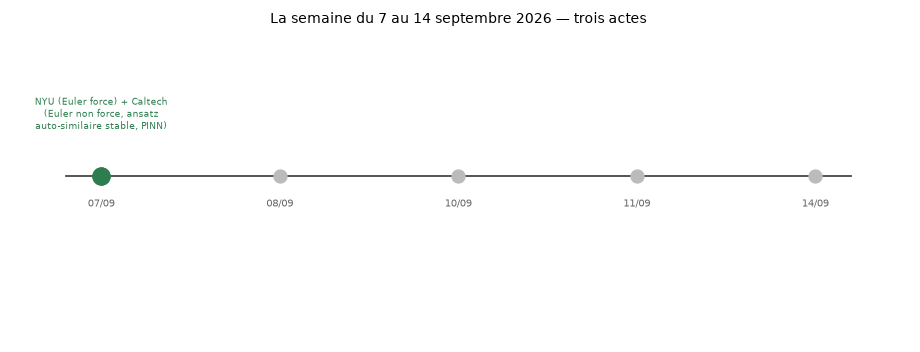

In [11]:
# Code 8.1 - Frise animee de la chronologie (7-14 septembre 2026)
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import io
import os
import tempfile
from matplotlib.animation import PillowWriter
from IPython.display import Image as IPyImage


def embed_gif(anim, fps=8, label="", colors=128):
    # Sauve l'animation en GIF et l'affiche (visible sur GitHub, pas un jshtml).
    # PillowWriter n'accepte ici que fps ; la taille se reduit par dpi/frames/STEP.
    with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp:
        gif_path = tmp.name
    anim.save(gif_path, writer=PillowWriter(fps=fps))
    with open(gif_path, "rb") as fh:
        gif_bytes = fh.read()
    os.unlink(gif_path)
    print(f"GIF {label} : {len(gif_bytes) / 1024:.0f} Ko")
    return IPyImage(data=gif_bytes)


EVENTS = [
    ("07/09", "NYU (Euler force) + Caltech\n(Euler non force, ansatz\nauto-similaire stable, PINN)", "#2e7d4f"),
    ("08/09", "OpenAI annonce\nNavier-Stokes/Euler\n(le depot accompagne ici)", "#1a5f7a"),
    ("10/09", "Guest post Anandkumar\nsur le blog de Tao\n(anteriorite, methode)", "#8a5cc4"),
    ("11/09", "25 medailles Fields :\nsevere misalignment\n(AI vs mathematiques)", "#b3402a"),
    ("14/09", "Phadikar, Wolfram Community :\nexploration intuitive\n+ visualisation", "#c9a227"),
]

fig, ax = plt.subplots(figsize=(11.5, 4.4), dpi=80)
ax.set_xlim(0, len(EVENTS))
ax.set_ylim(-1.9, 1.6)
ax.axis("off")
ax.set_title("La semaine du 7 au 14 septembre 2026 — trois actes", fontsize=13, pad=14)

ax.plot([0.3, len(EVENTS) - 0.3], [0, 0], color="#444444", lw=1.6, zorder=1)
for i, (date, label, color) in enumerate(EVENTS):
    x = i + 0.5
    ax.scatter([x], [0], s=140, color="#bbbbbb", zorder=2)
    ax.text(x, -0.35, date, ha="center", fontsize=9, color="#666666")

texts = []
for i, (date, label, color) in enumerate(EVENTS):
    x = i + 0.5
    t = ax.text(x, 0.55 if i % 2 == 0 else -1.75, label, ha="center",
                fontsize=8.4, color=color, alpha=0.0)
    texts.append((x, color, t))


def update(frame):
    i = frame // 2
    if i < len(EVENTS):
        x, color, t = texts[i]
        ax.scatter([x], [0], s=240, color=color, zorder=3)
        t.set_alpha(1.0)
    return []


anim = animation.FuncAnimation(fig, update, frames=len(EVENTS) * 2, interval=900, blit=False)
plt.tight_layout()
plt.close(fig)
embed_gif(anim, fps=1.2, label="frise chronologique")

### Lecture du résultat

La frise rend visible ce que le tableau énonce : **trois actes**, pas une annonce isolée. Le premier (vert) est scientifique et **antérieur à OpenAI** ; le second (rouge) est un débat de communauté sur la place de l'IA ; le troisième (doré) est l'appropriation — c'est dans ce troisième acte que s'inscrivent l'article de Wolfram Community et ce notebook. L'animation n'ajoute aucune information au tableau ; elle rend l'ordre et la densité de la semaine **sensibles**, ce qu'une liste de dates ne fait pas.

> **Note de méthode** : la frise est un **GIF** généré par du code déterministe (un `FuncAnimation` sur des données écrites dans la cellule), affiché via `IPython.display.Image`. Aucune image n'est produite par un modèle : c'est la réponse concrète à la leçon des flèches de la section 8.3, et le GIF reste visible dans la version committée, y compris sur GitHub.

## 9. Lire l'écoulement : une reconstruction visuelle

### 9.1 Ce que l'article de Wolfram Community fait admirablement — et ce qu'on y ajoute

L'exploration de Jayanta Phadikar ([Wolfram Community, 28013](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013)) fait le travail que le dépôt ne faisait pas : elle donne une **intuition géométrique** de la construction en zones. Cette section s'en inspire — et le cite — sans le copier, en poussant la représentation plus loin sur trois points précis :

| Point | Article Wolfram | Ce notebook |
|---|---|---|
| Couleur | flèches teintées par zone | **échelle continue** par scalaire (vorticité, énergie, u_θ, u_r) |
| Vecteurs | flèches de direction | vecteurs **de taille variable** proportionnelle à l'amplitude, colorés par u_θ |
| Temps | figure fixe | **GIFs animés** : l'écoulement se resserre vers la rupture quand t → T* |

### 9.2 Une reconstruction qualitative, pas le candidat certifié

**Avertissement de portée.** Ce qui suit est un **modèle didactique**. Il est construit à partir des lois d'échelle citées dans l'article — écoulement azimutal de fond `u_{θ,bg} ~ q^{-1/2-h}`, pulses d'onde `A_wave ~ q^{-1/2-h/2}`, avec `h > 0` et `q → 0` — et de la structure en quatre zones (cœur singulier, régions 1 à 3). Ce n'est **ni** le candidat certifié d'OpenAI (dont la vérification est l'objet des sections 1–6), **ni** le profil auto-similaire d'Anandkumar : c'est un écoulement **pédagogique** dont le seul rôle est de rendre lisibles des scalaires et des directions qu'un texte ne montre pas. Le critère BKM de la section 2 donne la clé de lecture : c'est la **vorticité** qui porte la rupture, et c'est elle que la première figure suit en couleur continue.

D:\dev\CoursIA\venv\Lib\site-packages\matplotlib\transforms.py:2115: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx[0, 1] *= sx
D:\dev\CoursIA\venv\Lib\site-packages\matplotlib\transforms.py:2116: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx[0, 2] *= sx
D:\dev\CoursIA\venv\Lib\site-packages\matplotlib\transforms.py:2117: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx[1, 0] *= sy
D:\dev\CoursIA\venv\Lib\site-packages\matplotlib\transforms.py:2119: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx[1, 2] *= sy


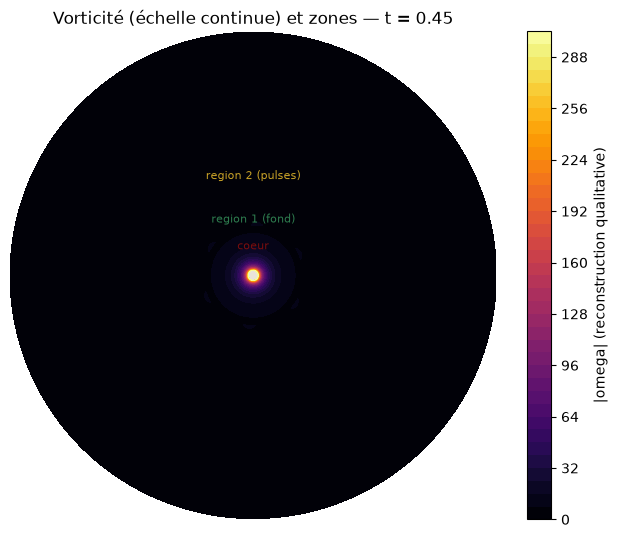

Champ didactique construit : u_r, u_theta, omega, energy sur une grille 200 x 200
Lois d'echelle (article Wolfram 28013) : u_theta,bg ~ q^(-1/2-h) ; A_wave ~ q^(-1/2-h/2)
Zones : coeur, region 1 (fond), region 2 (pulses), region 3 (externe).
Rappel : reconstruction qualitative, PAS le candidat certifie (cf. section 6).


In [12]:
# Code 9.1 - Ecoulement auto-similaire didactique : champ, zones et scalaires
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Grille polaire sur le disque (r in (0,1], theta in [0, 2*pi)).
N = 200
r = np.linspace(0.02, 1.0, N)
theta = np.linspace(0, 2 * np.pi, N)
R, TH = np.meshgrid(r, theta)
X = R * np.cos(TH)
Y = R * np.sin(TH)

H_EXP = 0.18  # h > 0 ; les lois d'echelle viennent de l'article Wolfram (28013).

ZONES = [
    ("coeur", 0.0, 0.35, "#7a0d0d"),
    ("region 1 (fond)", 0.35, 0.75, "#2e7d4f"),
    ("region 2 (pulses)", 0.75, 1.4, "#c9a227"),
    ("region 3 (externe)", 1.4, np.inf, "#6b7f8f"),
]


def v_core(t):
    # Rayon du coeur singulier : v(t) -> 0 quand t -> T* (T* normalise a 1).
    return max(0.06, 0.5 * (1.0 - t))


def fields(t):
    # Retourne (u_r, u_theta, omega, energy, q) sur la grille, a l'instant t in [0,1).
    v = v_core(t)
    q = np.clip(R / v, 1e-3, None)
    # Fond azimutal : u_theta,bg ~ q^(-1/2 - h)
    u_theta_bg = np.power(q, -0.5 - H_EXP)
    # Pulses d'onde (region 2) : A_wave ~ q^(-1/2 - h/2), oscillants en angle et en temps.
    region2 = (q > 0.75) & (q < 1.4)
    a_wave = np.power(q, -0.5 - H_EXP / 2.0)
    pulse = np.where(region2, a_wave * np.sin(6.0 * TH + 8.0 * t), 0.0)
    u_theta = u_theta_bg + 0.35 * pulse
    # Composante radiale : faible, oscillante dans la region 2 (modulations entrantes/sortantes).
    u_r = np.where(region2, 0.18 * a_wave * np.cos(6.0 * TH + 8.0 * t), 0.0)
    # Vorticite (scalaire) : omega ~ (1/r) d(r u_theta)/dr, amplifiee pres du coeur.
    omega_bg = np.power(q, -0.5 - H_EXP) / np.clip(R, 1e-3, None)
    omega = omega_bg + np.where(
        region2, 0.5 * a_wave * np.cos(6.0 * TH + 8.0 * t) / np.clip(R, 1e-3, None), 0.0)
    energy = 0.5 * (u_r ** 2 + u_theta ** 2)
    return u_r, u_theta, omega, energy, q


# Apercu statique a mi-parcours pour fixer les zones.
u_r, u_theta, omega, energy, q = fields(0.45)
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.set_aspect("equal")
v = v_core(0.45)
for name, q0, q1, color in ZONES:
    r1 = q1 * v
    ax.add_patch(plt.Circle((0, 0), r1, color=color, alpha=0.06, fill=True))
    if np.isfinite(r1):
        ax.text(0, r1, name, ha="center", va="bottom", fontsize=8, color=color)
cs = ax.contourf(X, Y, omega, levels=40, cmap="inferno")
ax.set_title("Vorticité (échelle continue) et zones — t = 0.45")
fig.colorbar(cs, ax=ax, shrink=0.8, label="|omega| (reconstruction qualitative)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("Champ didactique construit : u_r, u_theta, omega, energy sur une grille", N, "x", N)
print("Lois d'echelle (article Wolfram 28013) : u_theta,bg ~ q^(-1/2-h) ; A_wave ~ q^(-1/2-h/2)")
print("Zones : coeur, region 1 (fond), region 2 (pulses), region 3 (externe).")
print("Rappel : reconstruction qualitative, PAS le candidat certifie (cf. section 6).")

### Lecture du résultat

La figure statique fixe le vocabulaire visuel : **quatre zones** concentriques (cœur, fond, pulses, externe), une **vorticité en échelle continue** (`inferno`) qui s'embrase vers le centre. Deux points de lecture :

1. **la couleur est le critère.** Conformément à BKM (section 2), c'est l'explosion de `|ω|` près du cœur qui signe la rupture — pas la taille des vecteurs. La vorticité est donc le seul scalaire en échelle continue non bornée de la série ;
2. **les zones ne sont pas des régions arbitraires.** Leurs frontières sont des rayons réduits `q = r / v(t)` : quand le temps avance, le cœur `v(t)` se resserre et les frontières se déplacent vers le centre. C'est cette contraction que les GIFs suivants animent.

GIF vorticité : 99 Ko


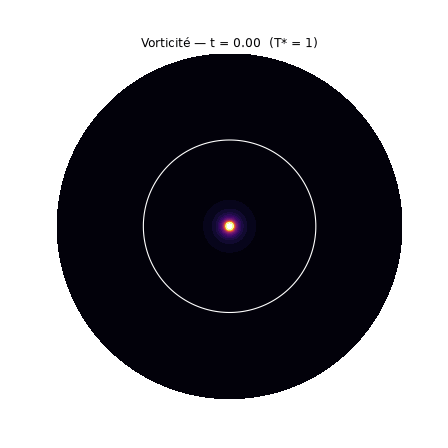

In [13]:
# Code 9.2 - GIF 1 : vorticite en echelle continue, contraction vers la rupture
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import io
import os
import tempfile
from matplotlib.animation import PillowWriter
from IPython.display import Image as IPyImage


def embed_gif(anim, fps=8, label="", colors=128):
    # Sauve l'animation en GIF et l'affiche (visible sur GitHub, pas un jshtml).
    # PillowWriter n'accepte ici que fps ; la taille se reduit par dpi/frames/STEP.
    with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp:
        gif_path = tmp.name
    anim.save(gif_path, writer=PillowWriter(fps=fps))
    with open(gif_path, "rb") as fh:
        gif_bytes = fh.read()
    os.unlink(gif_path)
    print(f"GIF {label} : {len(gif_bytes) / 1024:.0f} Ko")
    return IPyImage(data=gif_bytes)


FRAMES = 26
fig, ax = plt.subplots(figsize=(5.6, 5.6), dpi=80)
ax.set_aspect("equal")
ax.set_axis_off()


def draw(i):
    t = i / (FRAMES - 1) * 0.92
    u_r, u_theta, omega, energy, q = fields(t)
    ax.clear()
    ax.set_aspect("equal")
    ax.set_axis_off()
    v = v_core(t)
    cs = ax.contourf(X, Y, omega, levels=40, cmap="inferno")
    ax.contour(X, Y, R, levels=[v], colors="white", linewidths=1.0)
    ax.set_title(f"Vorticité — t = {t:.2f}  (T* = 1)", fontsize=11)
    return cs


anim = FuncAnimation(fig, draw, frames=FRAMES, interval=120, blit=False)
plt.close(fig)
embed_gif(anim, fps=8, label="vorticité")

### Lecture du résultat

Le GIF montre le **resserrement** : à mesure que `t → T*`, le rayon du cœur `v(t)` décroît, les zones se contractent et la vorticité s'embrase au centre en échelle continue. C'est exactement le contenu du critère BKM lu en image : l'intégrale temporelle de `‖ω‖_{L∞}` diverge parce que le suprême spatial s'envole sur un support qui se referme. La boucle blanche matérialise la frontière du cœur ; sa disparition progressive est la signature visuelle de la rupture.

GIF vecteurs de vitesse : 867 Ko


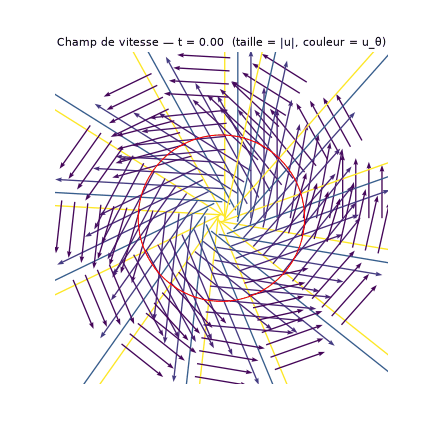

In [14]:
# Code 9.3 - GIF 2 : vecteurs de taille variable, colores par u_theta
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import io
import os
import tempfile
from matplotlib.animation import PillowWriter
from IPython.display import Image as IPyImage


def embed_gif(anim, fps=8, label="", colors=128):
    # Sauve l'animation en GIF et l'affiche (visible sur GitHub, pas un jshtml).
    # PillowWriter n'accepte ici que fps ; la taille se reduit par dpi/frames/STEP.
    with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp:
        gif_path = tmp.name
    anim.save(gif_path, writer=PillowWriter(fps=fps))
    with open(gif_path, "rb") as fh:
        gif_bytes = fh.read()
    os.unlink(gif_path)
    print(f"GIF {label} : {len(gif_bytes) / 1024:.0f} Ko")
    return IPyImage(data=gif_bytes)


STEP = 16
Xs = X[::STEP, ::STEP]
Ys = Y[::STEP, ::STEP]
THs = TH[::STEP, ::STEP]

FRAMES = 22
fig, ax = plt.subplots(figsize=(6.0, 6.0), dpi=72)
ax.set_aspect("equal")


def draw(i):
    t = i / (FRAMES - 1) * 0.92
    u_r, u_theta, omega, energy, q = fields(t)
    Ur = u_r[::STEP, ::STEP]
    Ut = u_theta[::STEP, ::STEP]
    Ux = Ur * np.cos(THs) - Ut * np.sin(THs)
    Uy = Ur * np.sin(THs) + Ut * np.cos(THs)
    ax.clear()
    ax.set_aspect("equal")
    ax.set_axis_off()
    qv = ax.quiver(Xs, Ys, Ux, Uy, Ut, cmap="viridis", scale_units="xy",
                   scale=2.0, width=0.004, headwidth=3.5)
    v = v_core(t)
    ax.contour(X, Y, R, levels=[v], colors="red", linewidths=1.1)
    ax.set_title(f"Champ de vitesse — t = {t:.2f}  (taille = |u|, couleur = u_θ)", fontsize=11)
    return qv


anim = FuncAnimation(fig, draw, frames=FRAMES, interval=120, blit=False)
plt.close(fig)
embed_gif(anim, fps=8, label="vecteurs de vitesse", colors=64)

### Lecture du résultat

Ce second GIF répond aux deux demandes de dépassement : les **vecteurs ont une taille variable** (proportionnelle à `|u|`, dominée par le fond azimutal près du cœur) et leur **couleur code `u_θ`** en échelle continue (`viridis`). On y lit trois choses que la Figure 1 statique ne montre pas :

1. **le fond tourne dans le même sens partout** — les flèches azimutales sont cohérentes dans les trois régions (c'est la question que Mark Neyrinck posait sur les régions 2 et 3) ;
2. **la région 2 ondule** : les pulses y ajoutent des composantes radiales et des modulations, visibles comme des variations locales de taille et de direction ;
3. **la rupture se lit en taille** : les flèches s'allongent démesurément près du cœur quand `t → T*` — l'amplitude diverge, mais c'est la vorticité (GIF 1) qui la certifie.

GIF quatre scalaires : 527 Ko


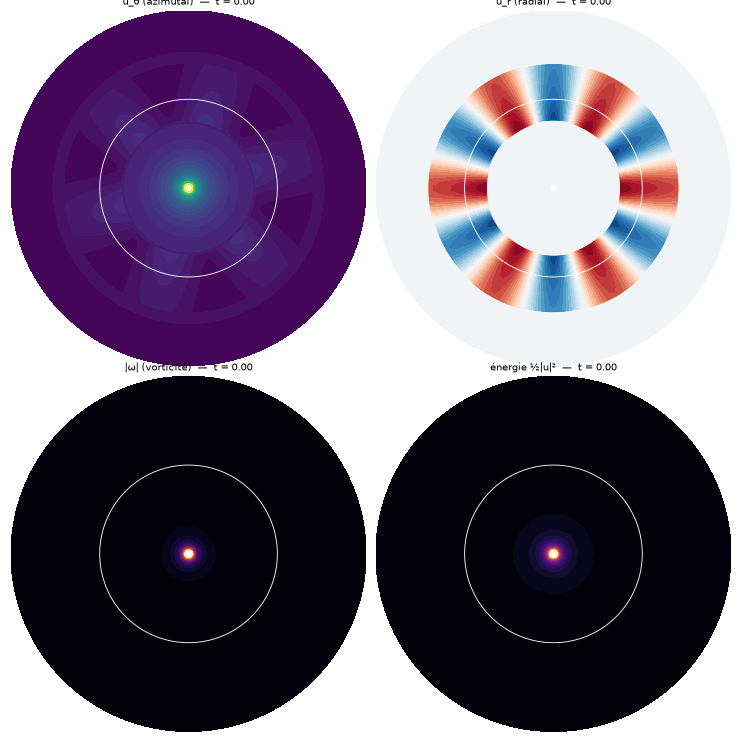

In [15]:
# Code 9.4 - GIF 3 : quatre scalaires en echelle continue, cote a cote
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import io
import os
import tempfile
from matplotlib.animation import PillowWriter
from IPython.display import Image as IPyImage


def embed_gif(anim, fps=8, label="", colors=128):
    # Sauve l'animation en GIF et l'affiche (visible sur GitHub, pas un jshtml).
    # PillowWriter n'accepte ici que fps ; la taille se reduit par dpi/frames/STEP.
    with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp:
        gif_path = tmp.name
    anim.save(gif_path, writer=PillowWriter(fps=fps))
    with open(gif_path, "rb") as fh:
        gif_bytes = fh.read()
    os.unlink(gif_path)
    print(f"GIF {label} : {len(gif_bytes) / 1024:.0f} Ko")
    return IPyImage(data=gif_bytes)


FRAMES = 22
fig, axes = plt.subplots(2, 2, figsize=(10.6, 10.6), dpi=70)
PANELS = [
    ("u_θ (azimutal)", "viridis", lambda t: fields(t)[1]),
    ("u_r (radial)", "RdBu_r", lambda t: fields(t)[0]),
    ("|ω| (vorticité)", "inferno", lambda t: np.abs(fields(t)[2])),
    ("énergie ½|u|²", "magma", lambda t: fields(t)[3]),
]
for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_axis_off()


def draw(i):
    t = i / (FRAMES - 1) * 0.92
    artists = []
    for ax, (label, cmap, getter) in zip(axes.ravel(), PANELS):
        ax.clear()
        ax.set_aspect("equal")
        ax.set_axis_off()
        cs = ax.contourf(X, Y, getter(t), levels=36, cmap=cmap)
        v = v_core(t)
        ax.contour(X, Y, R, levels=[v], colors="white", linewidths=0.9)
        ax.set_title(f"{label}  —  t = {t:.2f}", fontsize=10)
        artists.append(cs)
    return artists


anim = FuncAnimation(fig, draw, frames=FRAMES, interval=150, blit=False)
plt.tight_layout()
plt.close(fig)
embed_gif(anim, fps=6, label="quatre scalaires")

### Lecture du résultat

Le troisième GIF juxtapose les **quatre scalaires en échelle continue** — `u_θ`, `u_r`, `|ω|`, énergie — à quatre instants synchrones de la contraction. C'est la réponse directe à la demande « échelle continue de couleurs pour différents scalaires » : chaque panneau porte sa propre colormap, et la lecture croisée est le contenu :

| Panneau | Ce qu'il montre | Lecture |
|---|---|---|
| `u_θ` (viridis) | le fond azimutal dominant | divergence douce, même sens partout |
| `u_r` (RdBu_r) | la composante radiale | presque nulle hors région 2, oscillante dedans (entrantes/sortantes) |
| `|ω|` (inferno) | la vorticité | **seule divergence qui compte pour BKM** — embrasement au cœur |
| énergie (magma) | `½|u|²` | suit `u_θ`, concentre l'explosion près du centre |

Le contraste entre `u_r` (signé, `RdBu_r`) et les trois autres (positifs) rend la région 2 visible : c'est la seule où le radial n'est pas négligeable, exactement comme l'article le décrit.

### 9.3 Profils radiaux : la divergence en coupe

Pour terminer, une lecture quantitative de la même reconstruction : les profils radiaux de `u_θ` et de `|ω|` à plusieurs instants, en échelle log-log. C'est la coupe qui rend la loi d'échelle `q^{-1/2-h}` lisible comme une **pente** — et la divergence comme un déplacement de cette pente vers la gauche (vers `q → 0`).

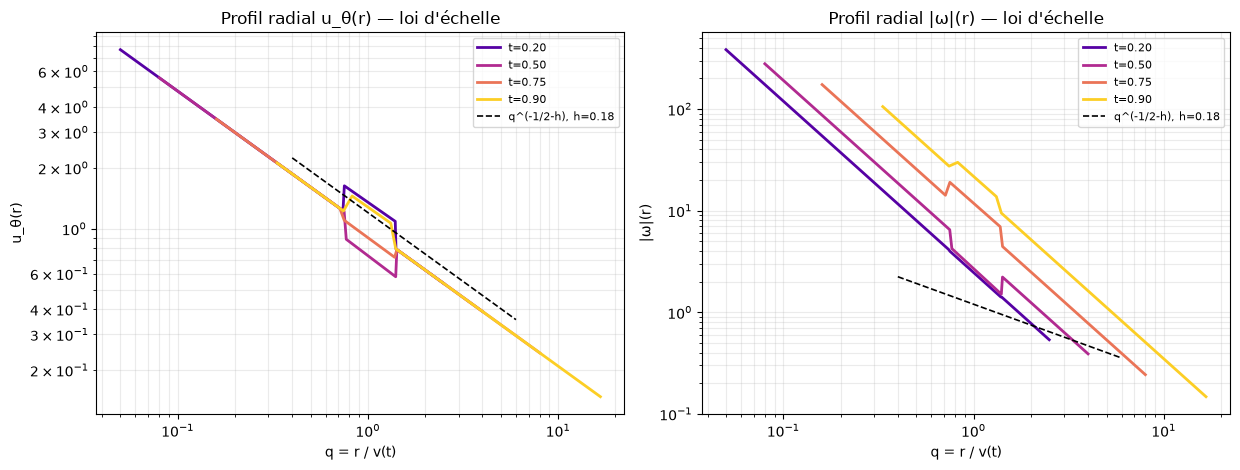

Les profils se deplacent vers q -> 0 quand t -> T* : la pente q^(-1/2-h) reste
la reference, mais le coeur v(t) se resserre, et la vorticite (a droite) s'eleve
plus vite que le champ azimutal (a gauche) -- c'est la lecture BKM en coupe.


In [16]:
# Code 9.5 - Profils radiaux : u_theta et |omega| en coupe log-log
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
times = [0.2, 0.5, 0.75, 0.9]
colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(times)))

r_line = r
for ax, (label, getter) in zip(axes, [
    ("u_θ(r)", lambda t: fields(t)[1][0]),
    ("|ω|(r)", lambda t: np.abs(fields(t)[2][0])),
]):
    for t, c in zip(times, colors):
        v = v_core(t)
        q_line = r_line / v
        ax.plot(q_line, getter(t), color=c, lw=2.0, label=f"t={t:.2f}")
    q_ref = np.linspace(0.4, 6.0, 50)
    ax.plot(q_ref, 1.2 * np.power(q_ref, -0.5 - H_EXP), "k--", lw=1.2,
            label=f"q^(-1/2-h), h={H_EXP}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("q = r / v(t)")
    ax.set_ylabel(label)
    ax.set_title(f"Profil radial {label} — loi d'échelle")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

print("Les profils se deplacent vers q -> 0 quand t -> T* : la pente q^(-1/2-h) reste")
print("la reference, mais le coeur v(t) se resserre, et la vorticite (a droite) s'eleve")
print("plus vite que le champ azimutal (a gauche) -- c'est la lecture BKM en coupe.")

### Lecture du résultat

La coupe log-log donne sa forme quantitative à la reconstruction : les profils suivent la pente de référence `q^{-1/2-h}` (pointillés), et se **translatent vers `q → 0`** quand `t` approche `T*`. Deux enseignements :

1. **l'auto-similarité se lit comme une invariance de pente** : à chaque instant, le profil est le même, à un changement d'échelle près — c'est la définition géométrique d'un ansatz auto-similaire, et c'est ce que le candidat d'OpenAI (multi-échelle) et celui d'Anandkumar (auto-similaire) formalisent de deux façons différentes ;
2. **la vorticité diverge plus vite que le champ** : à droite, `|ω|` s'élève plus raide que `u_θ` à gauche — c'est le sens précis du critère BKM, et la raison pour laquelle les GIFs 1 et 3 la mettent en couleur continue non bornée.

> **Rappel de portée (section 6)** : ces figures décrivent un **modèle didactique** dont les lois d'échelle viennent de l'article cité. Elles ne certifient ni le candidat d'OpenAI ni le profil d'Anandkumar ; elles rendent lisible une structure que le harnais, lui, vérifie mécaniquement sur l'artefact pinné.

## Conclusion

### Ce que ce notebook a établi

| Section | Résultat |
|---|---|
| 1 | un cadre d'exécution qui **ne fabrique aucune valeur** : le rapport du harnais est une entrée requise, et son absence fait échouer la cellule plutôt que de produire un affichage vide |
| 2 | la chaîne Euler en **dix maillons**, chacun rattaché à sa déclaration et à son fichier, avec **deux maillons `bridged`** nommés là où la conversion a réellement lieu, et la lecture BKM qui les relie |
| 3 | les **deux options du Comparator Navier–Stokes** — (C) sur ℝ³, (D) sur ℝ³/ℤ³ — et la **construction de candidat partagée** qui les alimente par deux portes distinctes, avec leurs deux mécanismes d'exclusion |
| 4 | la grille des **cinq classes**, avec vérification de l'énumération fermée, rattachement de chaque maillon à un fichier, et comptage des maillons par classe |
| 5 | la **re-dérivation** de `all_verified` depuis ses **huit** termes, dont les pins, le confinement fonctionnel et l'intégrité, puis depuis les quatre feuilles de chacun des deux gates |
| 6 | les **non-claims** : ce qu'un gate vert établit, ce qu'il n'établit pas, et le non-claim central sur le problème du millénaire |
| 8 | la **chronologie** de la semaine du 7 au 14 septembre 2026 — annonces, contre-publication, déclaration des 25 médaillés Fields — et la position de ce dépôt dans la discussion, avec une frise **animée** (GIF) |
| 9 | une **reconstruction visuelle** de l'écoulement, inspirée et citée de l'exploration Wolfram Community, poussée plus loin : **GIFs animés**, échelle continue de couleurs par scalaire, vecteurs de taille variable, profils radiaux en loi d'échelle — avec son avertissement de portée |

### Les quatre leçons à retenir

1. **Vérification mécanique et exposition mathématique sont deux objets distincts.** Un noyau accepte un artefact ; il ne lit pas la prose qui l'entoure. Les tenir séparés n'est pas une précaution rhétorique, c'est la condition pour qu'un résultat formel soit utilisable — et la semaine de septembre 2026 l'a démontré à l'échelle de la discipline.
2. **Un résumé est une affirmation, les feuilles sont l'évidence.** Re-dériver la conjonction du rapport rend visibles trois termes absents des gates : `dependency_pins_match`, `confinement.verified` et `integrity.verified`. Le dernier inclut les quatre signatures exactes de placeholders, pas seulement leur total.
3. **Classifier, c'est faire apparaître la structure — et rendre la classification réfutable.** Côté Euler, deux théorèmes de conversion nommés portent le passage entre le vocabulaire interne et celui du défi ; côté Navier–Stokes, cette conversion est absorbée dans la conclusion des adaptateurs, qui parlent déjà le vocabulaire du défi.
4. **L'image peut mentir là où le noyau ne peut pas.** L'épisode des flèches de la Figure 1 (article Wolfram) est un cas miniature : une figure générée par un modèle contenait des erreurs de direction que seule une relecture humaine a tranchées. Les visualisations de ce notebook sont donc **générées par du code déterministe** et relues — jamais produites par un générateur d'images.

### Ce qui reste, hors de ce notebook

| Chantier | Nature |
|---|---|
| Décider d'une voie d'adaptation (lake dédié à `v4.34.0-rc2`, ou migration d'un lake existant) | décision de filière, postérieure au gate |
| Le volet census de #15400 (matrice candidats → équivalents → probes) | a son propre cycle de vie ; ce notebook consomme le volet reproduction |
| Recontrôler fichier par fichier la classification de la §4 | contrôle possible — les fichiers sont cités pour cela |
| Approfondir la reconstruction de la §9 vers le profil auto-similaire certifié (splines + arithmétique d'intervalles) | chantier de recherche, hors portée pédagogique |

**État du gate de reproduction à l'exécution de ce notebook** : les deux commandes Comparator ont été exécutées séparément sur un hôte portant le sandbox requis, et **les deux gates sont verts** — Euler et Navier–Stokes acceptés par les deux kernels sous les seuls axiomes permis. Les pins de dépendances, le probe fonctionnel Landlock et le recensement d'intégrité sont également satisfaits.

### Pour aller plus loin

- le harnais : [`scripts/notebook_tools/nse_reproduction.py`](../../../scripts/notebook_tools/nse_reproduction.py) — mode `check` (agrégat falsifiable) ;
- le fil de l'issue : [#15400](https://github.com/jsboige/CoursIA/issues/15400) ; l'enrichissement visuel : [#16569](https://github.com/jsboige/CoursIA/issues/16569) ;
- le dépôt amont : [`openai/NavierStokesAndEuler`](https://github.com/openai/NavierStokesAndEuler), pin `8937a8f4…` ;
- la chronologie : [Tao, 10 sept. 2026](https://terrytao.wordpress.com/2026/09/10/stable-singularity-of-the-euler-equations-on-r3/) (guest post Anandkumar) · [Tao et 24 médaillés Fields, 11 sept. 2026](https://terrytao.wordpress.com/2026/09/11/a-severe-misalignment-of-ai-in-mathematics/) · [Phadikar, Wolfram Community, 14 sept. 2026](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013) ;
- la position du dépôt : [`docs/leiden-declaration-position.md`](../../../docs/leiden-declaration-position.md) ;
- dans la série : [Lean-28](Lean-28-Complex-Structure-S6.ipynb) pour la même méthode appliquée à une autre digestion mécanisée.

***

**Navigation** : [Sommaire de la série](README.md) · [<< Précédent : Lean-30](Lean-30-FormalGroups-Native.ipynb) · [Issue #15400](https://github.com/jsboige/CoursIA/issues/15400)
